# Configuration

In [2]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from phc_nzi.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from phc_nzi.mpb_configurator import *
from phc_nzi.mpi_differential_evolution import MPIdeOptimizator
from phc_nzi.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from phc_nzi.optimization_data_analyzer import OptimizationDataAnalyzer
from phc_nzi.simulation_viewer import SimulationViewer
from phc_nzi.lsf_sweeper import LSFSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 15

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps_inp = round(n_InP**2,2)
print("Epsilon of InP: ", eps_inp)

inp = Material(epsilon = eps_inp)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic_holes_1"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=True)
distance = 0.1
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance = distance)

print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms=1).make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms = 1, height_slab=0.5).make_C4v_diatomic_B()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

RESOLUTION = 32
## Define the simulation
configuration_options_2D = dict(
    resolution = RESOLUTION,
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)

configuration_options_2D_optimized = dict(
    resolution = RESOLUTION,
    num_bands=12,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)



configuration_options_slab = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)

configuration_options_slab_centered = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)


configuration_options_optimization = dict(
    resolution = RESOLUTION,
    num_bands=8,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = RESOLUTION,
    num_bands=10,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options_2D)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_2D_optimized = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_2D_optimized)
mpb_configuration_2D_sweep = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_sweep)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_sweep)
mpb_configuration_slab_opt_centered = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab_centered)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_2D_optimized = mpb_configuration_2D_optimized.get_scheme_config(join_newline=True)
script_2D_sweep = mpb_configuration_2D_sweep.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)
script_slab_opt_centered = mpb_configuration_slab_opt_centered.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_slab = name + "_slab"


name_2D_opt = name + "_2D_opt"
name_2D_sweep = name + "_2D_sweep"

name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"
name_slab_opt_centered = name + "_slab_opt_centered"

name_2D_optimized = name + "_2D_optimized"

data_rooth = "/work3/enrva/phc_nzi_data/MPB_data"
if not os.path.exists(data_rooth):
    os.makedirs(data_rooth)

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt_456 = Simulation(
    simulation_name=name_2D_opt + "_456",
    script = script_2D_opt +"_456",
    directory= os.path.join(data_rooth, name_2D_opt + "_456")
    )

simulation_2D_opt_345 = Simulation(
    simulation_name=name_2D_opt + "_345",
    script = script_2D_opt +"_345",
    directory= os.path.join(data_rooth, name_2D_opt + "_345")
    )

simulation_2D_sweep = Simulation(
    simulation_name=name_2D_sweep,
    script = script_2D_sweep,
    directory= os.path.join(data_rooth, name_2D_sweep)
    )

simulation_2D_optimized = Simulation(
    simulation_name=name_2D_optimized,
    script = script_2D_optimized,
    directory= os.path.join(data_rooth, name_2D_optimized)
    )


simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_opt_centered = Simulation(
    simulation_name=name_slab_opt_centered,
    script = script_slab_opt_centered,
    directory= os.path.join(data_rooth, name_slab_opt_centered)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )






numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="hosts", span_value=1, queue="fotonano",   mem = "1GB")


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.5, 0.0, 0.0>, Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.5, 0.0>, Vector3<0.5, 0.0, 0.0>], 'k_points_labels': ['X', '$\\Gamma$', 'M', 'X']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']


# 2D
## Unoptimized


2D simulation done
Epsilon loaded max value:  9.46


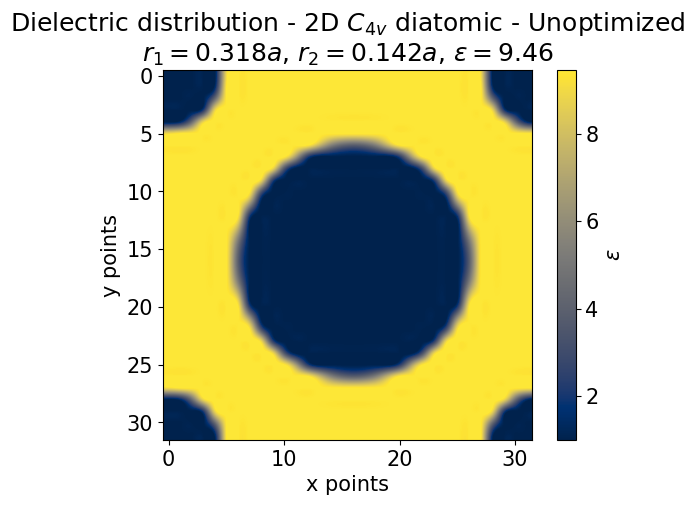

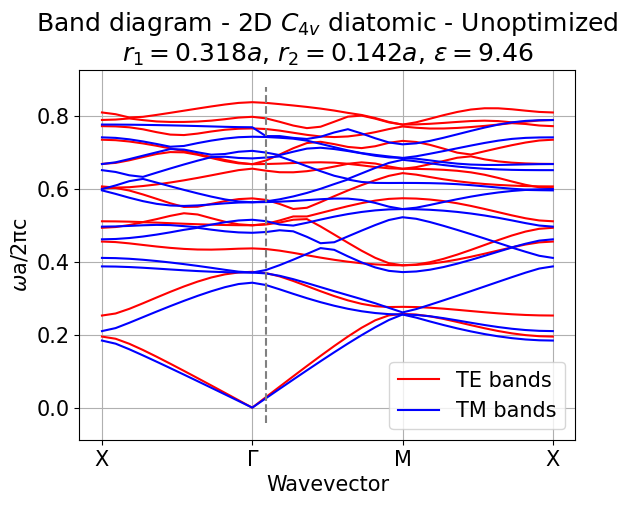

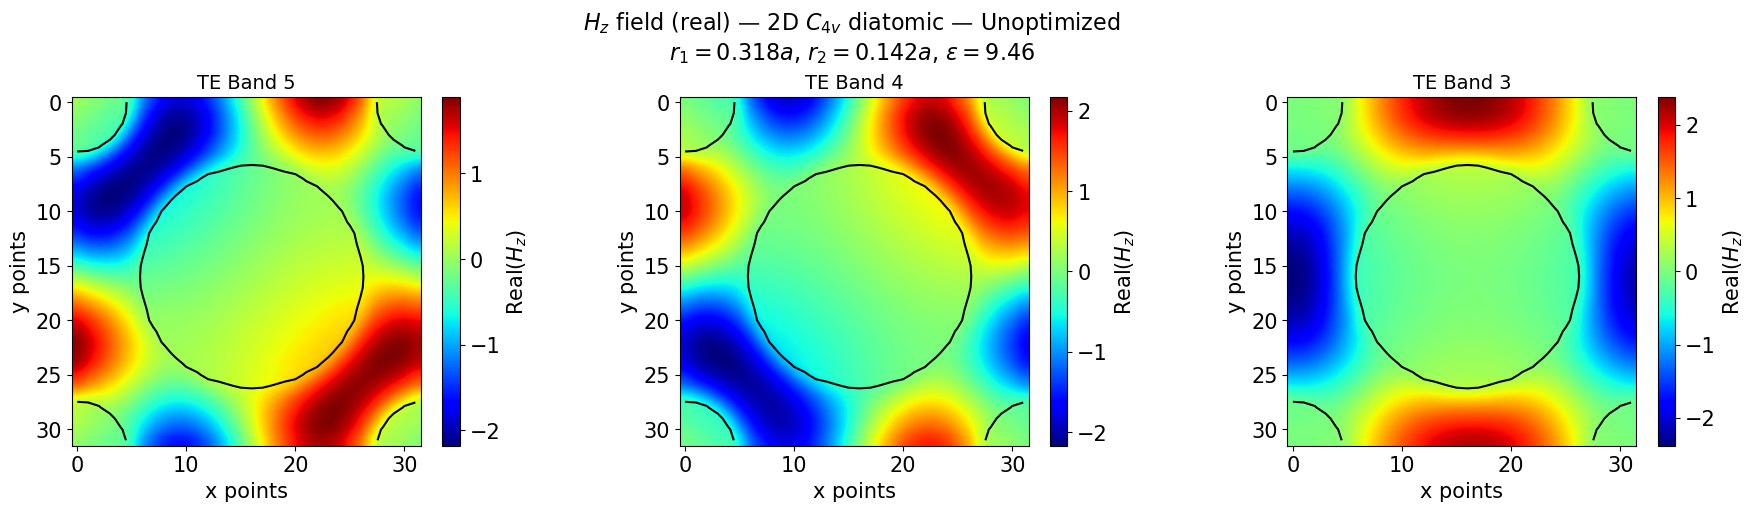

In [5]:
r1 = 0.317578
r2 = 0.142463


simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 1)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
eps_loaded = simulation_2D.load_and_convert_epsilon_data(options=opt)
print("Epsilon loaded max value: ", eps_loaded.max()) 
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:0.3f}a$, $r_2={r2:0.3f}a$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
viewer_2D.show()


viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
ymin, ymax = plt.ylim()
k_idx_for_field_plot = 13
plt.vlines(k_idx_for_field_plot, ymin, ymax, colors="gray", linestyles="--", label=None)
viewer_2D.show()

df_te = simulation_2D.load_frequency_data("te")
# display(df_te)

# --- Field plots with improved layout ---


band_indices = [5, 4, 3]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Unoptimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", "te", False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()

## Optimization


### Bands 4,5,6

Best point with filling_factor<0.3:  r1                0.215622
r2                0.289368
cost              0.000020
freq-dirac        0.553810
filling_factor    0.409120
Name: 236, dtype: float64
Best point with filling_factor>=0.3:  r1                0.372723
r2                0.297844
cost              0.000050
freq-dirac        0.744703
filling_factor    0.715131
Name: 72, dtype: float64


<Figure size 640x480 with 0 Axes>

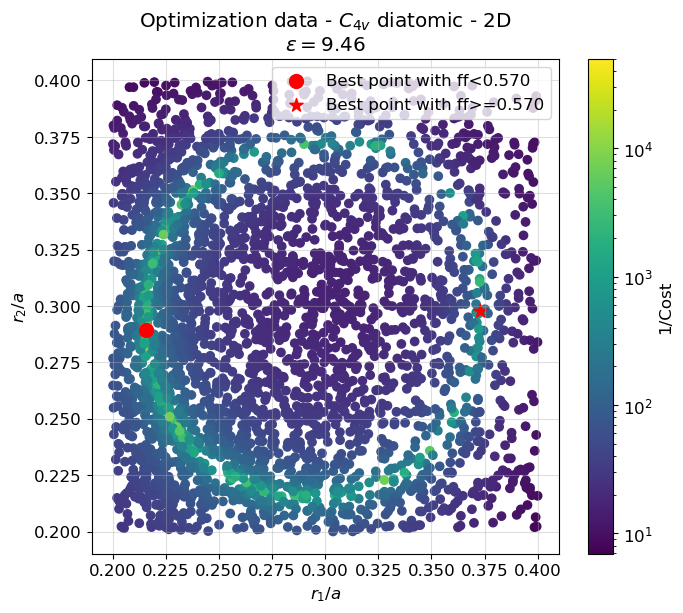

Weighted centroid: r1 = 0.2357, r2 = 0.2802
Best number of Fourier harmonics: 8


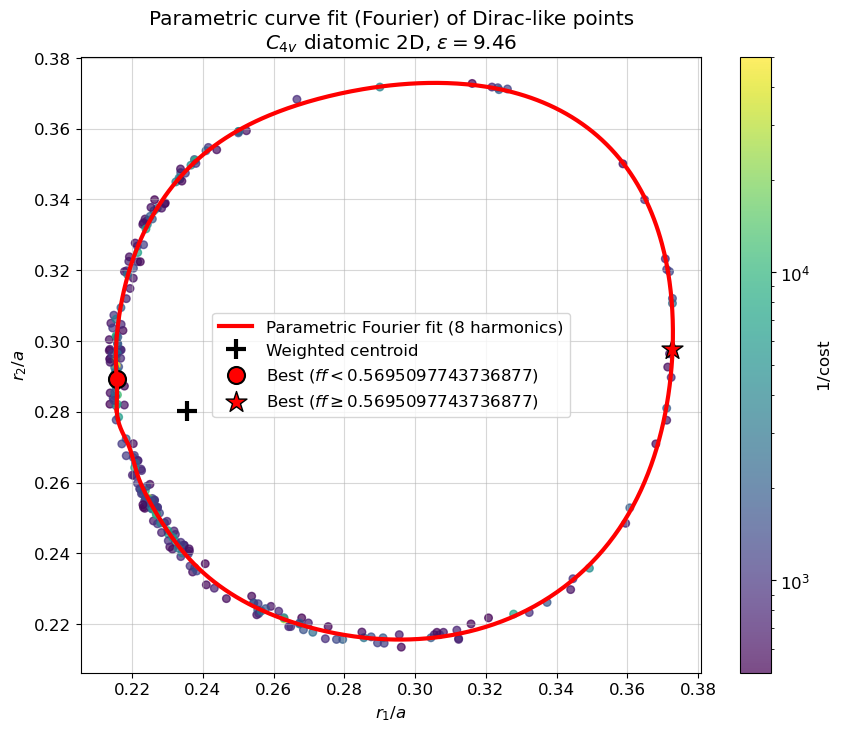


r1(θ) coefficients: a0=0.265217
  n=1: a_cos=0.072719, a_sin=0.003530
  n=2: a_cos=0.029602, a_sin=0.007554
  n=3: a_cos=0.005927, a_sin=0.003637
  n=4: a_cos=-0.000583, a_sin=0.000546
  n=5: a_cos=-0.000727, a_sin=-0.000082
  n=6: a_cos=-0.000808, a_sin=-0.000273
  n=7: a_cos=-0.000370, a_sin=-0.000265
  n=8: a_cos=-0.000197, a_sin=-0.000287

r2(θ) coefficients: c0=0.287235
  n=1: c_cos=0.003603, c_sin=0.060388
  n=2: c_cos=-0.006469, c_sin=0.029607
  n=3: c_cos=-0.003398, c_sin=0.006494
  n=4: c_cos=-0.000472, c_sin=0.000583
  n=5: c_cos=-0.000338, c_sin=0.000279
  n=6: c_cos=-0.000379, c_sin=-0.000350
  n=7: c_cos=0.000048, c_sin=-0.000569
  n=8: c_cos=0.000254, c_sin=-0.000307


,r1,r2,cost,freq-dirac,filling_factor
0,0.321720,0.371770,0.001227,0.767401,0.759375
1,0.223227,0.253016,0.001985,0.527515,0.357662
2,0.252320,0.359419,0.001614,0.679755,0.605850
3,0.360669,0.252862,0.000511,0.681931,0.609536
4,0.231875,0.246313,0.001351,0.530319,0.359511
...,...,...,...,...,...
258,0.238049,0.350186,0.000993,0.651179,0.563280
259,0.236138,0.241266,0.001684,0.529757,0.358049
260,0.215622,0.289368,0.000020,0.553810,0.409120
261,0.215622,0.289368,0.000020,0.553810,0.409120


,r1,r2,cost,freq-dirac,filling_factor
count,263.000000,263.000000,263.000000,263.000000,263.000000
mean,0.247062,0.276691,0.000928,0.577529,0.444203
std,0.043503,0.043799,0.000576,0.064242,0.106761
min,0.213572,0.213481,0.000020,0.523880,0.349725
25%,0.218911,0.241998,0.000454,0.531932,0.364577
50%,0.226849,0.267648,0.000906,0.553975,0.409120
75%,0.255720,0.304862,0.001362,0.597880,0.483980
max,0.372723,0.372787,0.001998,0.782383,0.789295


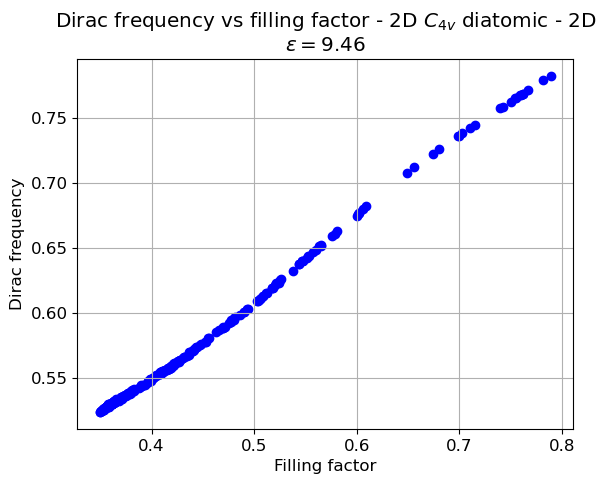

In [6]:
pop = 32
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt_456.simulation_name,
        scheme_script=simulation_2D_opt_456.script, 
        maxiter=50,
        param_names=["r1", "r2"],
        param_bounds=[(0.2, 0.4), (0.2, 0.4)],
        polarization="te",
        de_options={
            "strategy": "rand1bin",
            "popsize": pop,
            "mutation": (0.8, 1.5),
            "recombination": 0.3,
            "tol": 1e-12,
            "init": "latinhypercube",
        },
        bands=[4,5,6],
        directory=simulation_2D_opt_456.directory,
    )
# optimizer.erease_data_file()
# optimizer.submit_lsf_job(lsf_config, conda_env_name="mpb-nzi-env")
plt.rcParams["font.size"] = 12
analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure()
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.grid(alpha=0.4) 
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$") 
plt.title("Optimization data - $C_{4v}$ diatomic - 2D" + "\n" +rf"$\varepsilon={eps_inp}$")   



df = analyzer.get_points_above_treshold(500)

# add a column to the dataframe with the filling factor of the unit cell, calculated as the area of the two circles divided by the area of the unit cell
df["filling_factor"] = (np.pi * df["r1"]**2 + np.pi * df["r2"]**2) / 1**2

# Threshold for filling factor
ff_min, ff_max = df["filling_factor"].min(), df["filling_factor"].max()
threshold_ff = (ff_min + ff_max) / 2

# find the combination of r1 and r2 that gives the minimum cost coming from the points with filling factor below the threshold
best_point_below_threshold = df.loc[df[df["filling_factor"] < threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor<0.3: ", best_point_below_threshold)
r1_below_threshold, r2_below_threshold = best_point_below_threshold["r1"], best_point_below_threshold["r2"]

# find the point with the best cost among the points with filling factor above the threshold
best_point_above_threshold = df.loc[df[df["filling_factor"] >= threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor>=0.3: ", best_point_above_threshold)
r1_above_threshold, r2_above_threshold = best_point_above_threshold["r1"], best_point_above_threshold["r2"]


# plot the point with the best cost
plt.scatter(best_point_below_threshold["r1"], best_point_below_threshold["r2"], color="red", label=rf"Best point with ff<{threshold_ff:0.3f}", marker="o", s=100)
plt.scatter(best_point_above_threshold["r1"], best_point_above_threshold["r2"], color="red", label=rf"Best point with ff>={threshold_ff:0.3f}", marker="*", s=100)
plt.legend()
plt.show()

# Fit a parametric closed curve r1(θ), r2(θ) weighted by 1/cost
# using Fourier series in the angular parameter θ
weights = 1.0 / df["cost"].values
r1_data = df["r1"].values
r2_data = df["r2"].values

# 1. Weighted centroid
r1_center = np.average(r1_data, weights=weights)
r2_center = np.average(r2_data, weights=weights)
print(f"Weighted centroid: r1 = {r1_center:.4f}, r2 = {r2_center:.4f}")

# 2. Angular coordinate θ for each point relative to the centroid
theta_data = np.arctan2(r2_data - r2_center, r1_data - r1_center)

# 3. Fit r1(θ) and r2(θ) as truncated Fourier series, weighted by 1/cost
#    r1(θ) = a0 + Σ [an*cos(nθ) + bn*sin(nθ)]
#    r2(θ) = c0 + Σ [cn*cos(nθ) + dn*sin(nθ)]
def build_fourier_design_matrix(theta, n_harmonics):
    """Build design matrix for Fourier fit: 1, cos(θ), sin(θ), cos(2θ), sin(2θ), ..."""
    N = len(theta)
    cols = [np.ones(N)]
    for n in range(1, n_harmonics + 1):
        cols.append(np.cos(n * theta))
        cols.append(np.sin(n * theta))
    return np.column_stack(cols)

# Choose number of harmonics (try 3-8, pick best via weighted BIC)
best_n_harm = 3
best_bic = np.inf
for n_harm in range(3, 9):
    F = build_fourier_design_matrix(theta_data, n_harm)
    W = np.diag(weights)
    # Weighted least squares for r1 and r2
    FtWF = F.T @ W @ F
    try:
        coeffs_r1 = np.linalg.solve(FtWF, F.T @ W @ r1_data)
        coeffs_r2 = np.linalg.solve(FtWF, F.T @ W @ r2_data)
    except np.linalg.LinAlgError:
        continue
    r1_pred = F @ coeffs_r1
    r2_pred = F @ coeffs_r2
    n_params = 2 * (2 * n_harm + 1)
    n_pts = len(r1_data)
    residuals = weights * ((r1_data - r1_pred)**2 + (r2_data - r2_pred)**2)
    bic = n_pts * np.log(np.sum(residuals) / n_pts) + n_params * np.log(n_pts)
    if bic < best_bic:
        best_bic = bic
        best_n_harm = n_harm
        best_coeffs_r1 = coeffs_r1
        best_coeffs_r2 = coeffs_r2

print(f"Best number of Fourier harmonics: {best_n_harm}")

# Evaluate the parametric curve on a fine grid
theta_fine = np.linspace(-np.pi, np.pi, 1000)
F_fine = build_fourier_design_matrix(theta_fine, best_n_harm)
r1_curve = F_fine @ best_coeffs_r1
r2_curve = F_fine @ best_coeffs_r2

# Plot the parametric curve on top of the data
plt.figure(figsize=(10, 8))
sc = plt.scatter(r1_data, r2_data, c=1/df["cost"], cmap="viridis",
                 norm=colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max()),
                 s=30, alpha=0.7)
plt.colorbar(sc, label="$1/\\mathrm{cost}$")
plt.plot(r1_curve, r2_curve, "r-", linewidth=3, label=f"Parametric Fourier fit ({best_n_harm} harmonics)")
plt.plot(r1_center, r2_center, "k+", markersize=15, markeredgewidth=3, label="Weighted centroid")

# Mark best points
plt.scatter(best_point_below_threshold["r1"], best_point_below_threshold["r2"],
            color="red", marker="o", s=150, edgecolors="black", linewidths=1.5,
            label=rf"Best ($ff<{threshold_ff}$)")
plt.scatter(best_point_above_threshold["r1"], best_point_above_threshold["r2"],
            color="red", marker="*", s=250, edgecolors="black", linewidths=1.0,
            label=rf"Best ($ff\geq{threshold_ff}$)")

plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Parametric curve fit (Fourier) of Dirac-like points\n" + rf"$C_{{4v}}$ diatomic 2D, $\varepsilon={eps_inp}$")
plt.legend(loc="best")
plt.grid(True, alpha=0.5)
plt.axis("equal")
plt.show()

# Print Fourier coefficients
print(f"\nr1(θ) coefficients: a0={best_coeffs_r1[0]:.6f}")
for n in range(1, best_n_harm + 1):
    print(f"  n={n}: a_cos={best_coeffs_r1[2*n-1]:.6f}, a_sin={best_coeffs_r1[2*n]:.6f}")
print(f"\nr2(θ) coefficients: c0={best_coeffs_r2[0]:.6f}")
for n in range(1, best_n_harm + 1):
    print(f"  n={n}: c_cos={best_coeffs_r2[2*n-1]:.6f}, c_sin={best_coeffs_r2[2*n]:.6f}")

# dosplay the hole dataframe
display(df, df.describe())   

# In a new figure plot the freq-dirac against the filling factor
plt.figure()
plt.scatter(df["filling_factor"], df["freq-dirac"], color="blue")
plt.xlabel("Filling factor")
plt.ylabel("Dirac frequency")
plt.title("Dirac frequency vs filling factor - 2D $C_{4v}$ diatomic - 2D" + "\n" +rf"$\varepsilon={eps_inp}$")
plt.grid()
plt.show()

## Sweep

0.19 0.1


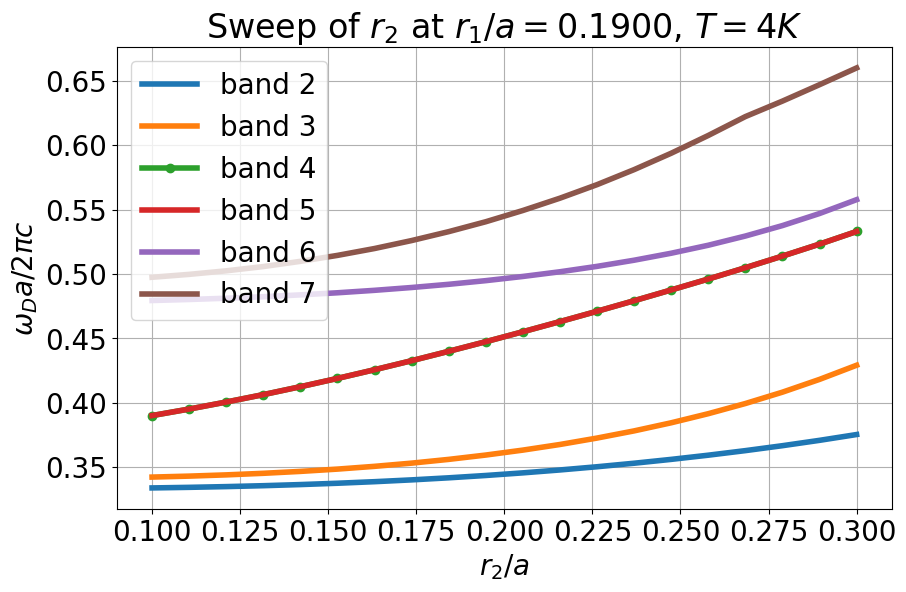

In [ ]:
# Sweep 2D 
# Instantiate the new sweeper
r1 = 0.19

values = np.linspace(0.1, 0.3, 20, endpoint=True)
sweeper = LSFSweeper(simulation_2D_sweep.simulation_name + "_r2_big", directory=simulation_2D_sweep.directory + "_r2_big",
                     scheme_script=simulation_2D_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="te",
                        bands=[2,3,4,5,6,7],
                        others_command_line_params={"r1": r1},
                       )

#Run the sweeper
# sweeper.submit_lsf_job(lsf_config)
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.figure(figsize=(10, 6))
plt.rcParams["font.size"] = 20
plt.rcParams["lines.linewidth"] = 4

plt.plot(df["r2"], df["band_2"], label="band 2")
plt.plot(df["r2"], df["band_3"], label="band 3")
plt.plot(df["r2"], df["band_4"], label="band 4", marker="o")
plt.plot(df["r2"], df["band_5"], label="band 5")
plt.plot(df["r2"], df["band_6"], label="band 6")
plt.plot(df["r2"], df["band_7"], label="band 7")

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
#plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {round(r2,5):0.5f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_6"] - df["band_4"]))

#plt.plot(df["r2"][idx_freq_dirac], df["band_6"][idx_freq_dirac], "go", label = f"$r_2/a ={round(df['r2'][idx_freq_dirac],5):0.5f}$, $\omega_Da/2\pi c = {df['band_4'][idx_freq_dirac]:0.4f}$, \n $\lambda_0 = 1550nm $, a = {df['band_4'][idx_freq_dirac]*1550:0.0f}nm") 
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + f"$T = {T}K$, $\epsilon_{{InP}}(T)={eps}$")
plt.legend()
plt.title(f"Sweep of $r_2$ at $r_1/a = {r1:0.4f}$, $T={T}K$")
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

c0 = 299792458



r1:  0.24
r2:  0.234325297948492
0.24 0.234325297948492


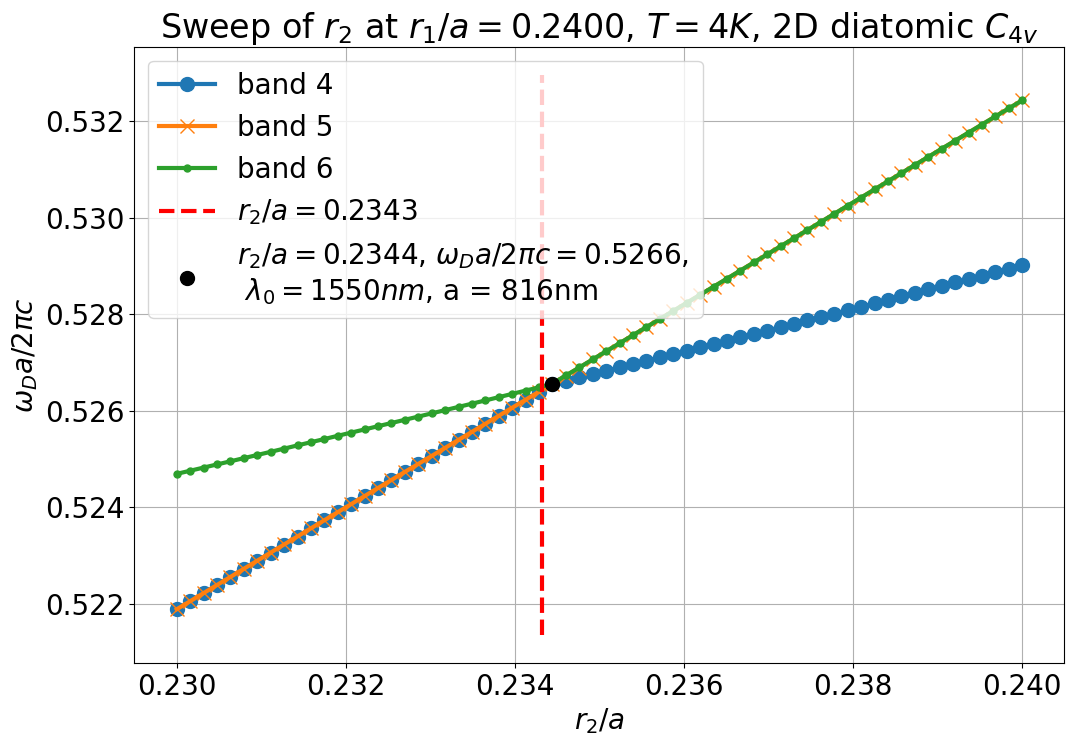

In [ ]:
# Sweep 2D 
# Instantiate the new sweeper
r1 = 0.24
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, a, "lower") 
print("r1: ", r1)
print("r2: ", r2)

values = np.linspace(0.23, 0.24, 64, endpoint=True)
sweeper = LSFSweeper(simulation_2D_sweep.simulation_name + "_r2", directory=simulation_2D_sweep.directory + "_r2",
                     scheme_script=simulation_2D_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="te",
                        bands=[4,5,6],
                        others_command_line_params={"r1": r1},
                       )

#Run the sweeper
# sweeper.submit_lsf_job(lsf_config)
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.rcParams["lines.linewidth"] = 3
plt.figure(figsize=(12, 8))
ms = 10

plt.plot(df["r2"], df["band_4"], "o-",  label="band 4", markersize=ms)
plt.plot(df["r2"], df["band_5"], "x-",label="band 5", markersize=ms)
plt.plot(df["r2"], df["band_6"], ".-", label="band 6", markersize=ms)

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {round(r2,5):0.4f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_6"] - df["band_4"]))

plt.scatter(df["r2"][idx_freq_dirac], df["band_6"][idx_freq_dirac], 100, "k", label = f"$r_2/a ={round(df['r2'][idx_freq_dirac],5):0.4f}$, $\omega_Da/2\pi c = {df['band_4'][idx_freq_dirac]:0.4f}$, \n $\lambda_0 = 1550nm $, a = {df['band_4'][idx_freq_dirac]*1550:0.0f}nm", zorder = 5) 
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + f"$T = {T}K$, $\epsilon_{{InP}}(T)={eps}$")
plt.legend()
plt.title(f"Sweep of $r_2$ at $r_1/a = {r1:0.4f}$, $T={T}K$, 2D diatomic $C_{{4v}}$ ")
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

c0 = 299792458



## Optimized

### Above FF threshold

r2:  0.29784408447837607 r1:  0.37272276943706906 filling factor:  0.7151312962493602
2D simulation done


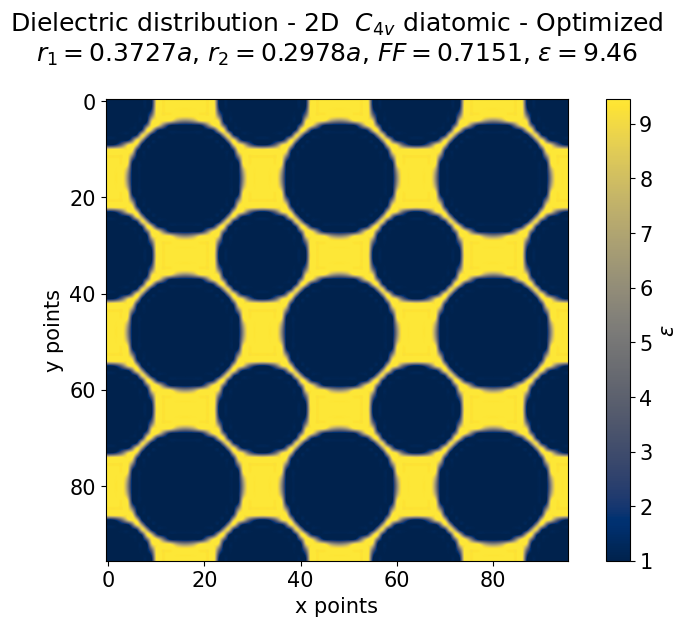

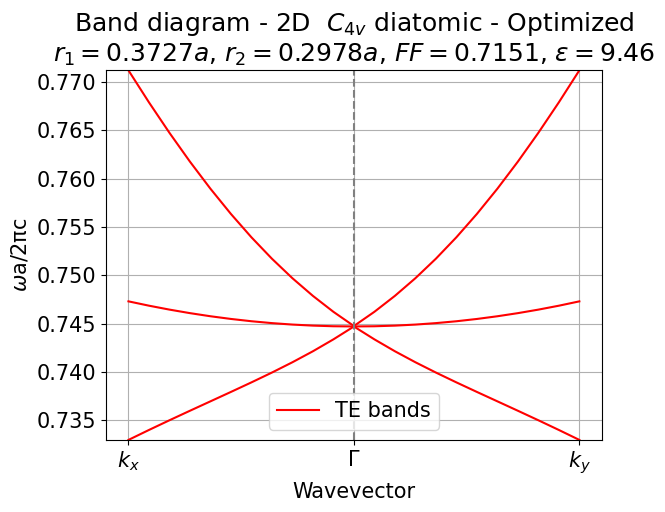

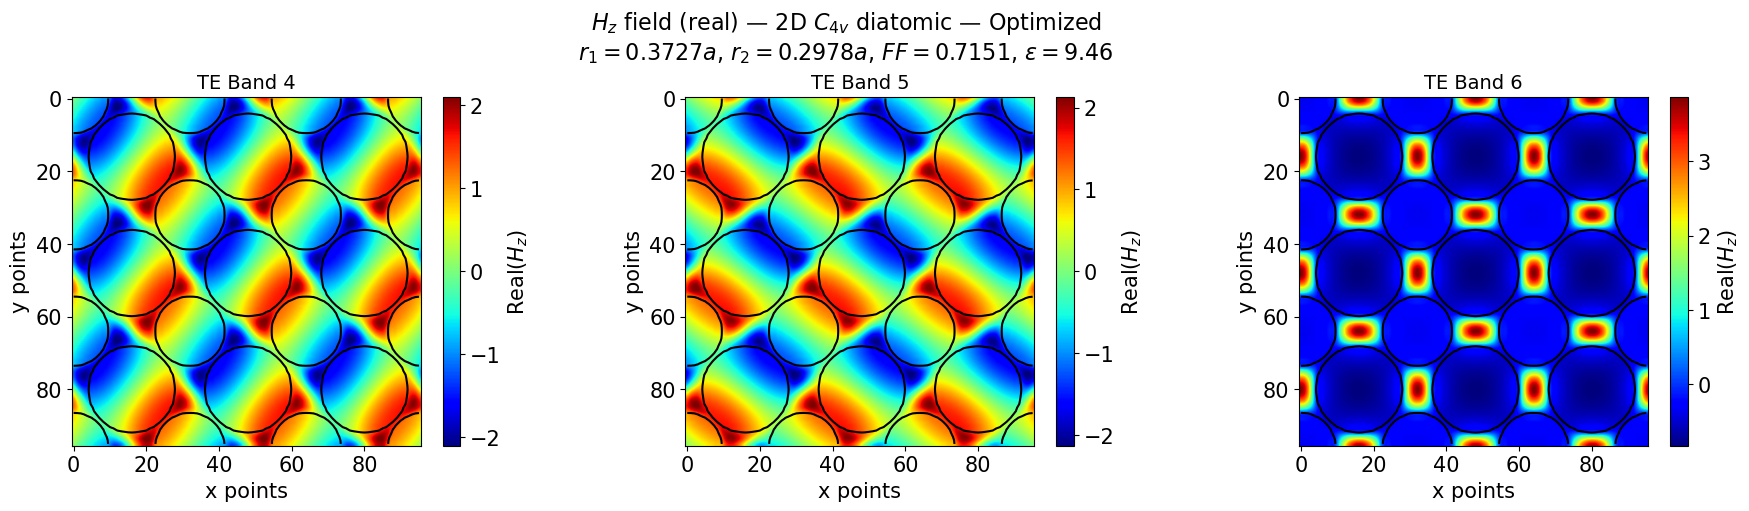

In [7]:
r1 = r1_above_threshold
r2 = r2_above_threshold
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
plt.rcParams["font.size"] = 15


simulation_2D_optimized.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D_optimized) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure(figsize=(10, 6))
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
viewer_2D.show()

#viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue")
viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = simulation_2D_optimized.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

len_k_points = len(k_points["k_points_values"])

plt.ylim(min_freq, max_freq)


ax = plt.gca()
k_idx_for_field_plot = 12
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, color="gray", linestyle="--", label=None)
viewer_2D.show()

# --- Field plots ---


band_indices = [4,5,6]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Optimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", polarization.lower(), False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()



### Below FF Threshold

r2:  0.2893684110882849 r1:  0.21562231086468173 filling factor:  0.40912036958598136


2D simulation done


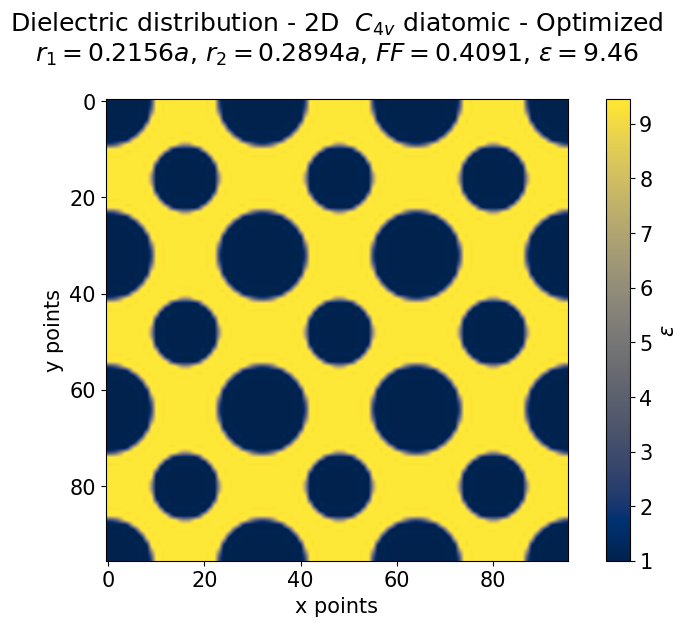

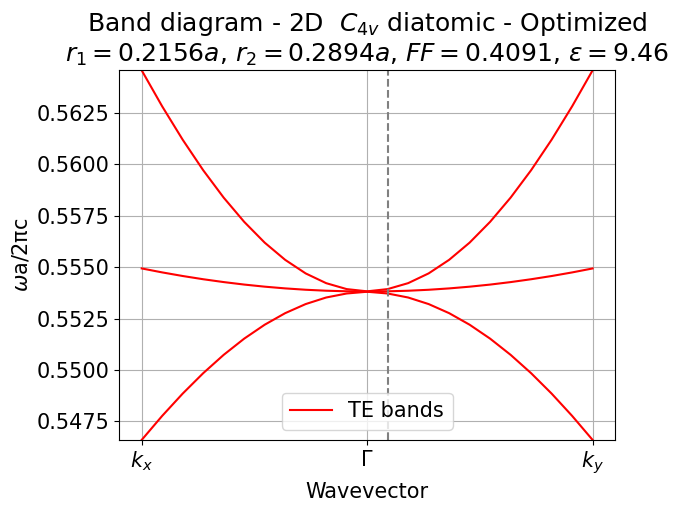

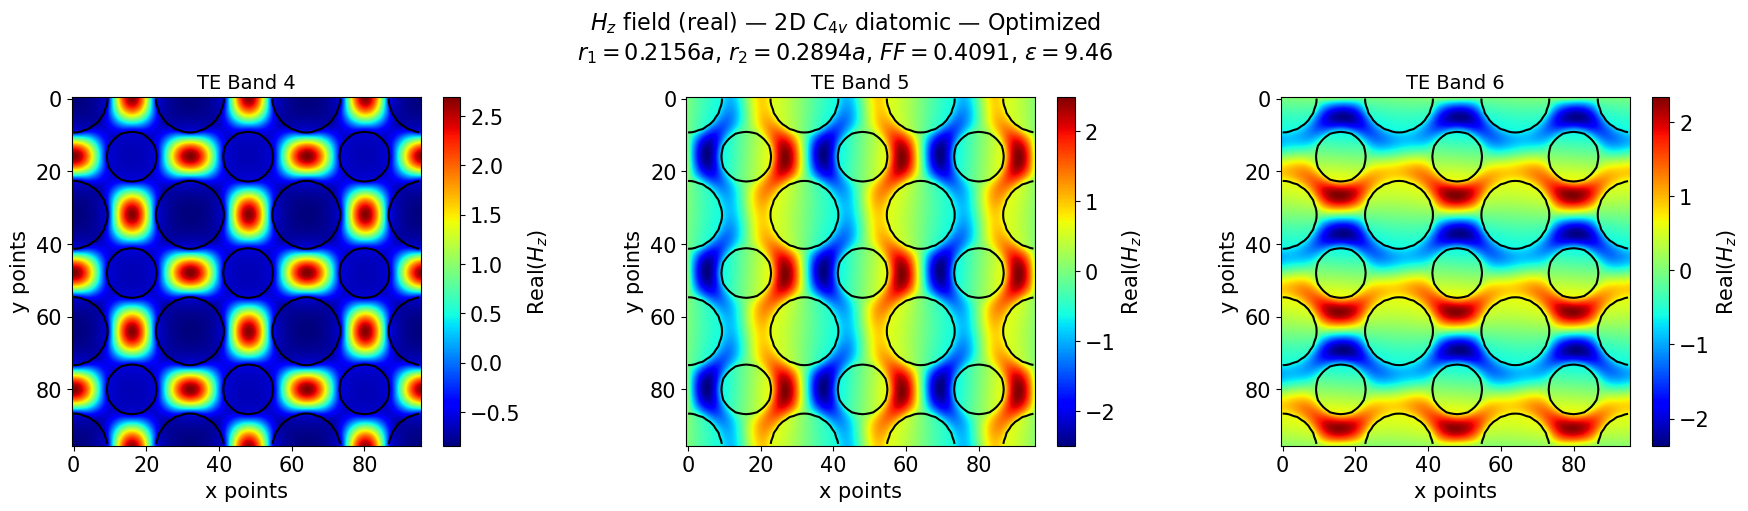

In [8]:
r1 = r1_below_threshold
r2 = r2_below_threshold
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
plt.rcParams["font.size"] = 15


simulation_2D_optimized.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D_optimized) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure(figsize=(10, 6))
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
viewer_2D.show()

viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red")
# viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = simulation_2D_optimized.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

plt.ylim(min_freq, max_freq)


ax = plt.gca()

k_idx_for_field_plot = 13
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, colors="gray", linestyles="--", label=None)


# plt.title("")
viewer_2D.show()

# --- Field plots with improved layout ---


band_indices = [4,5,6]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Optimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", polarization.lower(), False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()



Saving figures to: /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_4_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_5_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_6_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profiles_combined_r1_0.2156_r2_0.2894_eps_9.46.png


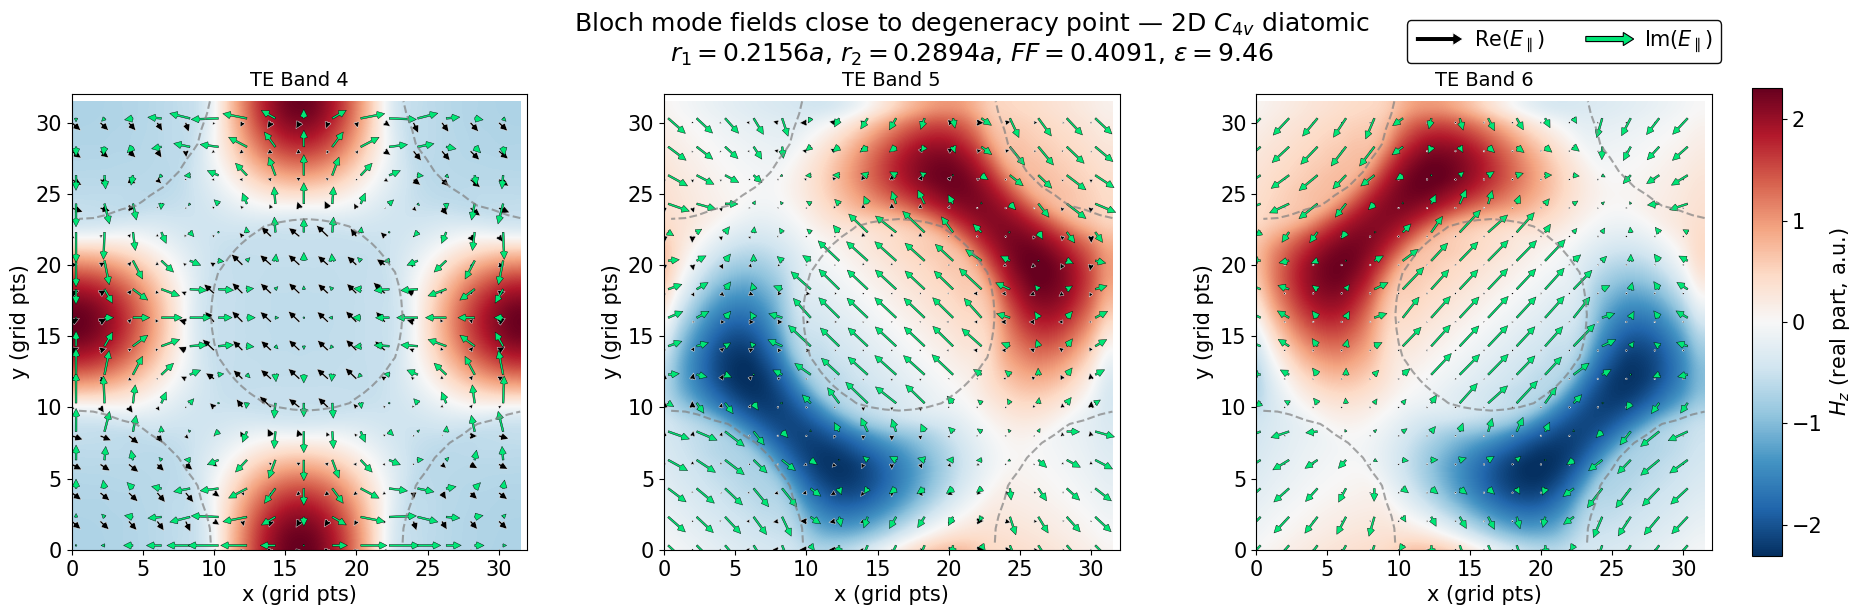

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from matplotlib.legend_handler import HandlerPatch
import os

fontsize_content = 15
plt.rcParams["font.size"] = fontsize_content
fontsize_title = 18


# --- Arrow colors ---
COLOR_RE = 'black'
COLOR_IM = '#00E676'        # bright green
EDGE_RE  = 'white'
EDGE_IM  = 'black'

# Build a parameter-stamped subfolder: figures/r1_XXXX_r2_XXXX_eps_XX
param_tag = f"r1_{r1:.4f}_r2_{r2:.4f}_eps_{eps_inp:.2f}"
SAVE_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "phd", "figures", param_tag)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving figures to: {SAVE_DIR}")


class ArrowHandler(HandlerPatch):
    """Custom legend handler that draws an arrow instead of a rectangle."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        arrow = FancyArrow(
            xdescent, ydescent + height / 2,
            width * 0.9, 0,
            width=height * 0.35,
            head_width=height * 0.9,
            head_length=width * 0.25,
            fc=orig_handle.get_facecolor(),
            ec=orig_handle.get_edgecolor(),
            linewidth=0.8,
            transform=trans
        )
        return [arrow]


def _add_arrow_legend(fig_or_ax, is_figure=False, **kwargs):
    """Add arrow-style legend for Re/Im E_parallel."""
    arrow_re = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_RE, ec=EDGE_RE)
    arrow_im = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_IM, ec=EDGE_IM)
    target = fig_or_ax.legend if is_figure else fig_or_ax.legend
    return target(
        [arrow_re, arrow_im],
        [r'$\mathrm{Re}(E_{\parallel})$', r'$\mathrm{Im}(E_{\parallel})$'],
        handler_map={FancyArrow: ArrowHandler()},
        ncol=2, fontsize=fontsize_content,
        framealpha=0.95, facecolor='white', edgecolor='black',
        **kwargs
    )


def plot_field_quiver_on_ax(ax, k_idx, b_idx):
    """Plot H_z background with E-field quiver arrows on a given axes."""
    opt = MPBDataOptions(rectify=True, periods=1, transpose=False)

    H_field = simulation_2D_optimized.load_and_convert_field_data(
        k_idx, b_idx, "z", "te", "h", conversion_options=opt)
    E_field_x = simulation_2D_optimized.load_and_convert_field_data(
        k_idx, b_idx, "x", "te", "e", conversion_options=opt)
    E_field_y = simulation_2D_optimized.load_and_convert_field_data(
        k_idx, b_idx, "y", "te", "e", conversion_options=opt)

    H_real = np.real(H_field)
    vmax_h = np.max(np.abs(H_real))
    im = ax.imshow(H_real, interpolation='spline36', cmap="RdBu_r",
                   vmin=-vmax_h, vmax=vmax_h, origin='lower')

    step = 2
    ny, nx = H_field.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]

    Ex_r = np.real(E_field_x)[::step, ::step]
    Ey_r = np.real(E_field_y)[::step, ::step]
    Ex_i = np.imag(E_field_x)[::step, ::step]
    Ey_i = np.imag(E_field_y)[::step, ::step]

    mag_real = np.sqrt(Ex_r**2 + Ey_r**2)
    mag_imag = np.sqrt(Ex_i**2 + Ey_i**2)
    max_mag = max(mag_real.max(), mag_imag.max())
    arrow_scale = max_mag * 15

    ax.quiver(X_sub, Y_sub, Ex_r, Ey_r,
              color=COLOR_RE, edgecolor=EDGE_RE, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    offset = 0.3
    ax.quiver(X_sub + offset, Y_sub + offset, Ex_i, Ey_i,
              color=COLOR_IM, edgecolor=EDGE_IM, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    try:
        eps_data = simulation_2D_optimized.load_and_convert_epsilon_data(options=opt)
        ax.contour(eps_data, levels=[eps_data.max() * 0.5],
                   colors='gray', linewidths=1.5, linestyles='--',
                   alpha=0.7, origin='lower')
    except Exception:
        pass

    ax.set_xlabel("x (grid pts)")
    ax.set_ylabel("y (grid pts)")
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_aspect('equal')
    return im


# ============================================================
# 1) Save each band as a separate figure (no title, with cbar)
# ============================================================
band_indices = [4, 5, 6]
for b_idx in band_indices:
    fig_s, ax_s = plt.subplots(figsize=(7, 6))
    im_s = plot_field_quiver_on_ax(ax_s, 12, b_idx)
    plt.colorbar(im_s, ax=ax_s, label=r"$H_{z}$ (real part, a.u.)",
                 shrink=0.82, pad=0.02, aspect=25)
    _add_arrow_legend(ax_s, loc='upper right')
    fig_s.tight_layout()
    fname = os.path.join(SAVE_DIR, f"mode_profile_TE_band_{b_idx}_{param_tag}.png")
    fig_s.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close(fig_s)
    print(f"Saved → {fname}")


# ============================================================
# 2) Combined figure with 3 subplots (with title)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

for ax, b_idx in zip(axes, band_indices):
    im = plot_field_quiver_on_ax(ax, 12, b_idx)
    ax.set_title(f"TE Band {b_idx}", fontsize=14)

# Layout: leave room for suptitle on top, legend at bottom, colorbar right
fig.subplots_adjust(left=0.05, right=0.87, bottom=0.13, top=0.85, wspace=0.30)

# Shared colorbar
cbar_ax = fig.add_axes([0.89, 0.13, 0.015, 0.72])
fig.colorbar(im, cax=cbar_ax, label=r"$H_{z}$ (real part, a.u.)")

# Arrow legend — top right
_add_arrow_legend(fig, is_figure=True,
                  loc='upper right',
                  bbox_to_anchor=(0.88, 0.97))

fig.suptitle(
    r"Bloch mode fields close to degeneracy point — 2D $C_{4v}$ diatomic"
    + "\n" + data_line,
    fontsize=fontsize_title, y=0.97
)

fname_combined = os.path.join(SAVE_DIR, f"mode_profiles_combined_{param_tag}.png")

fig.savefig(fname_combined, dpi=200, bbox_inches='tight')
print(f"Saved → {fname_combined}")
plt.show()

### Band Linearity Analysis
Evaluate the linearity of the top Dirac-cone band (band 6) for points along the optimization ellipse.

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Sampling 40 points along the Dirac ellipse
  r1 range: [0.2153, 0.3734]
  r2 range: [0.2150, 0.3753]


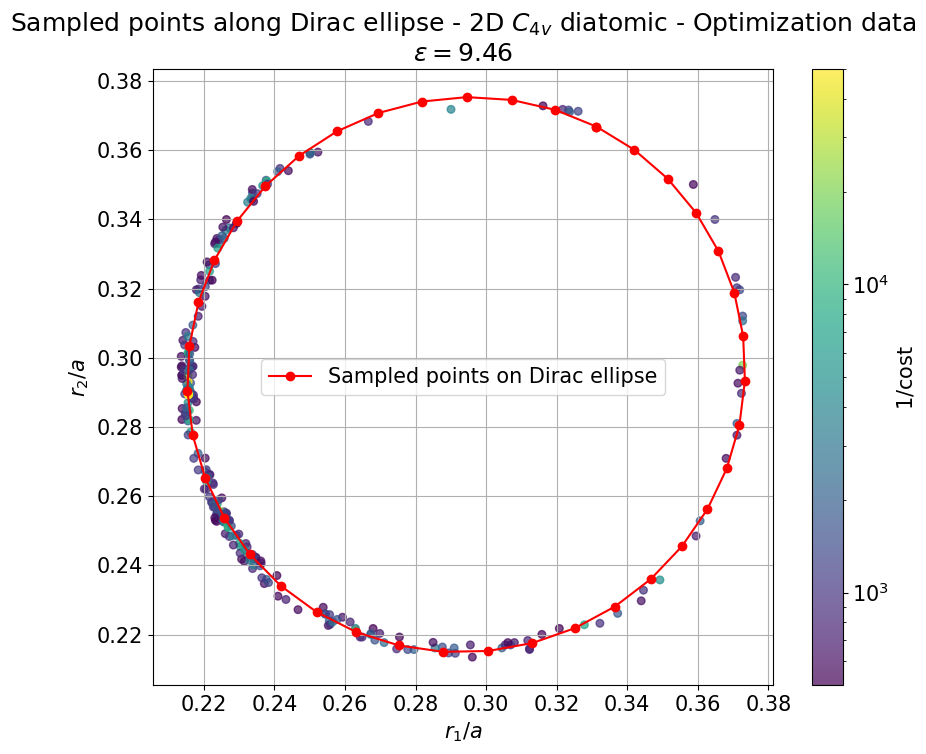

  [1/40] r1=0.3312, r2=0.3668 ... done
  [2/40] r1=0.3195, r2=0.3716 ... done
  [3/40] r1=0.3072, r2=0.3745 ... done
  [4/40] r1=0.2945, r2=0.3753 ... done
  [5/40] r1=0.2818, r2=0.3740 ... done
  [6/40] r1=0.2695, r2=0.3707 ... done
  [7/40] r1=0.2577, r2=0.3654 ... done
  [8/40] r1=0.2470, r2=0.3583 ... done
  [9/40] r1=0.2374, r2=0.3496 ... done
  [10/40] r1=0.2294, r2=0.3395 ... done
  [11/40] r1=0.2230, r2=0.3282 ... done
  [12/40] r1=0.2184, r2=0.3160 ... done
  [13/40] r1=0.2159, r2=0.3033 ... done
  [14/40] r1=0.2153, r2=0.2904 ... done
  [15/40] r1=0.2168, r2=0.2776 ... done
  [16/40] r1=0.2203, r2=0.2653 ... done
  [17/40] r1=0.2258, r2=0.2537 ... done
  [18/40] r1=0.2330, r2=0.2432 ... done
  [19/40] r1=0.2418, r2=0.2341 ... done
  [20/40] r1=0.2519, r2=0.2265 ... done
  [21/40] r1=0.2632, r2=0.2207 ... done
  [22/40] r1=0.2753, r2=0.2169 ... done
  [23/40] r1=0.2878, r2=0.2150 ... done
  [24/40] r1=0.3005, r2=0.2152 ... done
  [25/40] r1=0.3131, r2=0.2175 ... done
  [26/40]

In [13]:
import pandas as pd
from scipy.stats import linregress

# Create a lean configuration: only frequencies, no field output
config_linearity = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor=15,
)
mpb_config_lin = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_linearity)
script_lin = mpb_config_lin.get_scheme_config(join_newline=True)

# Sample points along the Dirac-like ellipse from optimization data
threshold_lin = 500
n_samples = 40
r1_ell, r2_ell, f_ell, _ = analyzer.compute_freq_dirac_along_ellipse(
    threshold=threshold_lin, n_points=n_samples)
print(f"Sampling {n_samples} points along the Dirac ellipse")
print(f"  r1 range: [{r1_ell.min():.4f}, {r1_ell.max():.4f}]")
print(f"  r2 range: [{r2_ell.min():.4f}, {r2_ell.max():.4f}]")

# Plot the sampled points on top of the cost landscape
p1 = analyzer.param1_name
p2 = analyzer.param2_name
plt.figure(figsize=(10, 8))
df = analyzer.get_points_above_treshold(threshold_lin)
sc = plt.scatter(df[p1], df[p2], c=1/df["cost"], cmap="viridis", norm=colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max()), s=30, alpha=0.7)
plt.colorbar(sc, label="$1/\\mathrm{cost}$")
plt.plot(r1_ell, r2_ell, "ro-", label="Sampled points on Dirac ellipse")
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Sampled points along Dirac ellipse - 2D $C_{4v}$ diatomic - Optimization data\n" + rf"$\varepsilon={eps_inp}$")  
plt.legend()
plt.grid(True)
plt.show()

# Create a unique Simulation object for each ellipse point
sims_lin = []
for i, (r1_i, r2_i) in enumerate(zip(r1_ell, r2_ell)):
    sim_name = f"{name_2D_optimized}_lin_{i:03d}"
    sim = Simulation(
        simulation_name=sim_name,
        script=script_lin,
        directory=os.path.join(data_rooth, sim_name)
    )
    sims_lin.append({'r1': r1_i, 'r2': r2_i, 'sim': sim, 'f_dirac_approx': f_ell[i]})

# Run all simulations sequentially
for j, entry in enumerate(sims_lin):
    print(f"  [{j+1}/{len(sims_lin)}] r1={entry['r1']:.4f}, r2={entry['r2']:.4f} ...", end=" ", flush=True)
    entry['sim'].run_hpc(
        mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
        mpi=True, load_epsilon=False)
    print("done")

print(f"\nAll {len(sims_lin)} simulations completed.")

Analyzed 40/40 simulations


,r1,r2,filling_factor,c_linear,b_quad,a_cubic,fom,r_squared,gap_46,anisotropy
count,40.000000,40.000000,40.000000,4.000000e+01,40.000000,4.000000e+01,40.000000,40.000000,40.000000,40.000000
mean,0.295269,0.296881,0.429275,3.645850e-04,0.000079,1.324893e-06,0.261002,0.960412,0.002492,0.971870
std,0.056220,0.057855,0.152373,5.560906e-04,0.000056,1.771042e-06,0.380716,0.021393,0.003276,0.151282
min,0.215326,0.215012,0.223249,2.460010e-07,0.000028,5.740454e-09,0.000283,0.918608,0.000048,0.040560
25%,0.240695,0.241421,0.280909,4.468704e-05,0.000046,3.443520e-07,0.045464,0.939989,0.000245,0.995865
50%,0.297528,0.298313,0.426287,1.746582e-04,0.000053,5.244991e-07,0.110861,0.963686,0.000817,0.999285
75%,0.347868,0.353368,0.575359,4.176043e-04,0.000093,1.330732e-06,0.350881,0.978422,0.003296,0.999806
max,0.373353,0.375308,0.644212,2.656046e-03,0.000262,7.705151e-06,1.775662,0.997747,0.013104,1.000000


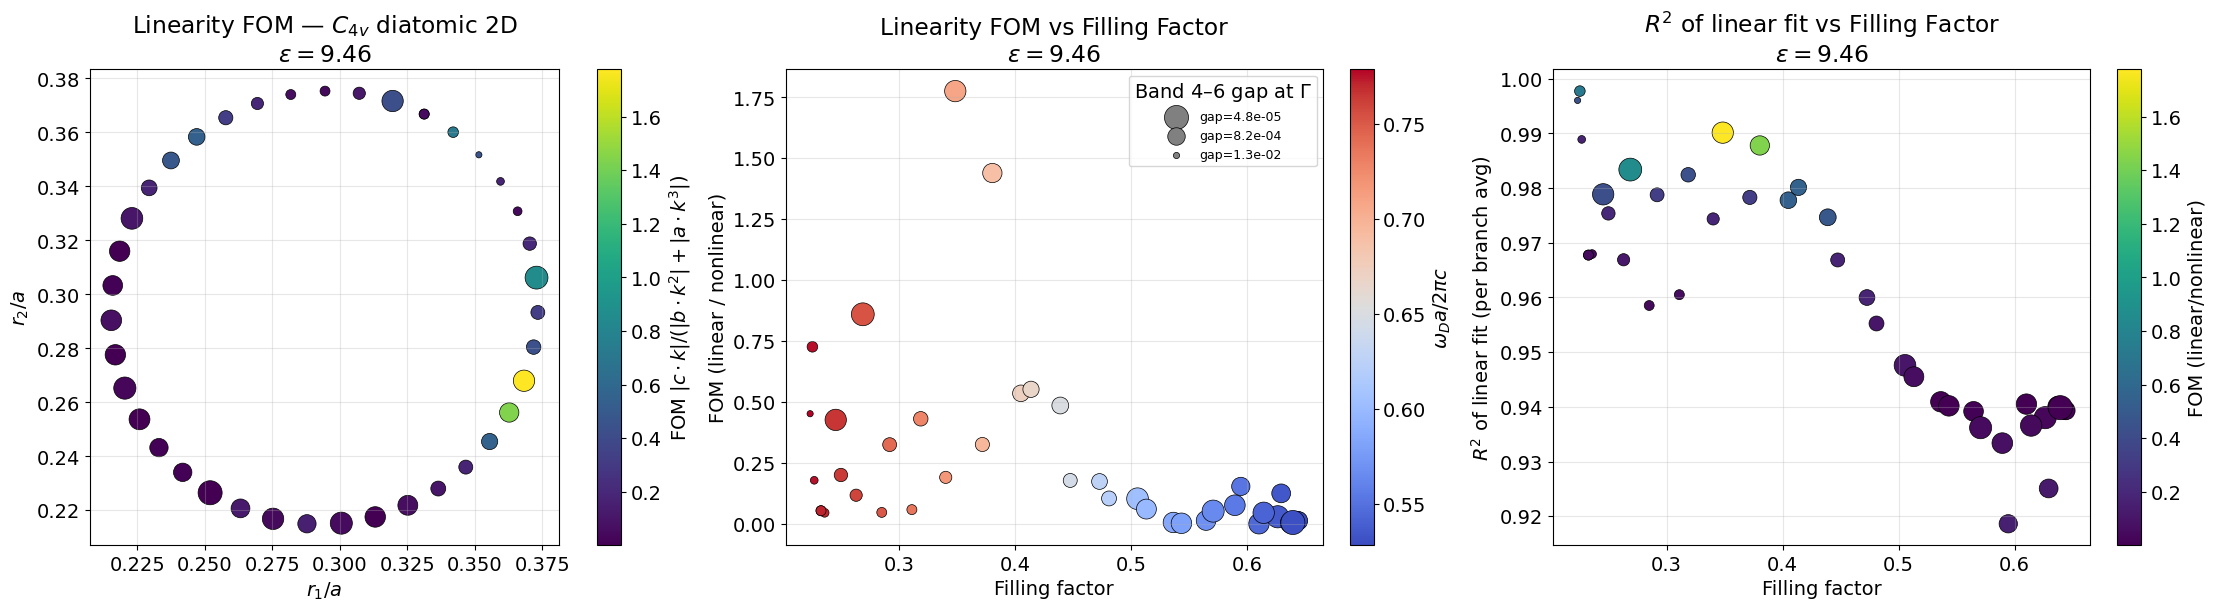

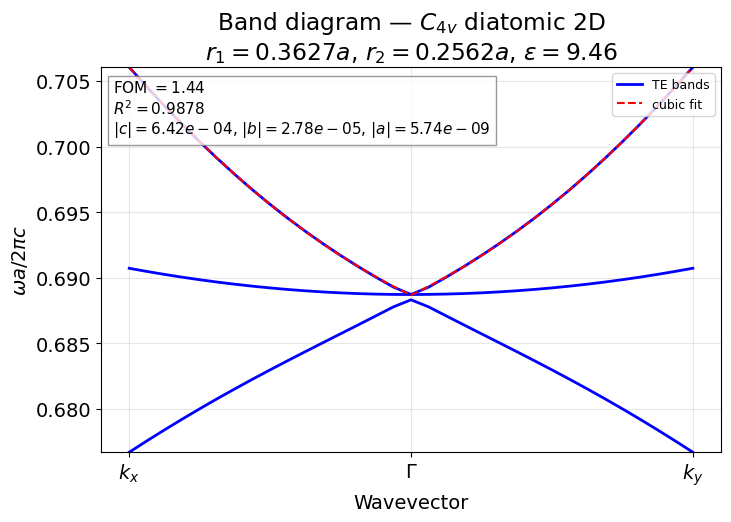

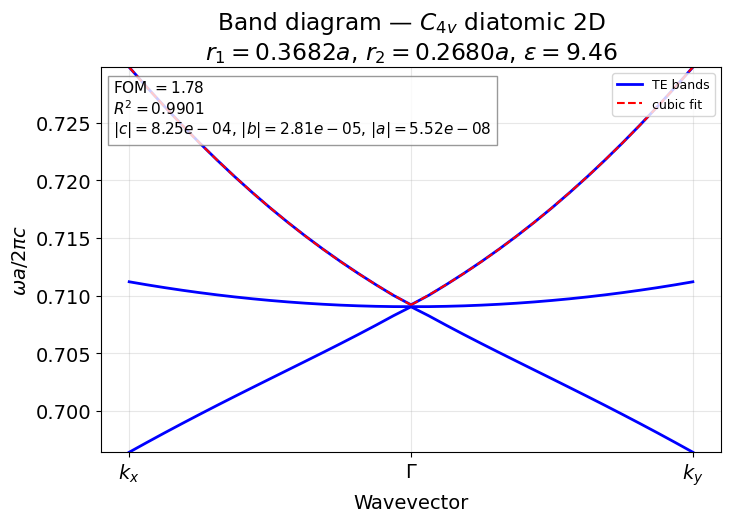

Saved 40 band diagrams to:
  /work3/enrva/phc_nzi_data/MPB_data/C4v_diatomic_holes_1_2D_optimized_linearity_bands


In [32]:
# Analyze linearity of band 6 (top band of Dirac triplet 4,5,6)
# Fit ω(Δk) = a·Δk³ + b·Δk² + c·Δk + d  with Δk centered at Γ
# FOM = |c·Δk_max| / (|b·Δk_max²| + |a·Δk_max³|)
#   → measures how much the LINEAR term dominates over nonlinear terms
results_lin = []
top_band_name = "te band 6"
FIT_ORDER = 3  # cubic fit

for entry in sims_lin:
    r1_i, r2_i, sim = entry['r1'], entry['r2'], entry['sim']
    try:
        df_freq = sim.load_frequency_data("te")
        k_idx = df_freq["k index"].values.astype(float)
        freqs = df_freq[top_band_name].values

        # Gamma is at the center of the k-path
        gamma_pos = len(k_idx) // 2
        omega_gamma = freqs[gamma_pos]
        k_gamma = k_idx[gamma_pos]

        # Center k at Gamma: Δk = k - k_Γ
        dk_all = k_idx - k_gamma

        # Fit each branch separately (with k centered at Gamma)
        # Left branch: Δk ≤ 0
        dk_left  = dk_all[:gamma_pos + 1]
        f_left   = freqs[:gamma_pos + 1]
        # Right branch: Δk ≥ 0
        dk_right = dk_all[gamma_pos:]
        f_right  = freqs[gamma_pos:]

        coeffs_L = np.polyfit(dk_left, f_left, FIT_ORDER)   # [a, b, c, d]
        coeffs_R = np.polyfit(dk_right, f_right, FIT_ORDER)

        # With k centered at Γ:  coeffs = [a, b, c, d]
        # c = linear (group velocity), b = quadratic, a = cubic
        a_L, b_L, c_L, d_L = coeffs_L
        a_R, b_R, c_R, d_R = coeffs_R

        # Average absolute coefficients from both branches
        a_avg = 0.5 * (abs(a_L) + abs(a_R))
        b_avg = 0.5 * (abs(b_L) + abs(b_R))
        c_avg = 0.5 * (abs(c_L) + abs(c_R))

        # k_max = max |Δk| across both branches
        dk_max = max(abs(dk_left.min()), abs(dk_right.max()))

        # FOM = |linear contribution| / |nonlinear contributions| at k_max
        linear_contrib    = c_avg * dk_max
        nonlinear_contrib = b_avg * dk_max**2 + a_avg * dk_max**3
        fom = linear_contrib / nonlinear_contrib if nonlinear_contrib > 1e-30 else np.inf

        # R² of a purely linear fit — computed PER BRANCH then averaged
        # (combined fit gives R²≈0 because branches have opposite slopes)
        _, _, r_L, _, _ = linregress(dk_left, f_left)
        _, _, r_R, _, _ = linregress(dk_right, f_right)
        r_squared = 0.5 * (r_L**2 + r_R**2)

        # Check isotropy: compare group velocities along kx and ky branches
        anisotropy = min(abs(c_L), abs(c_R)) / max(abs(c_L), abs(c_R)) if max(abs(c_L), abs(c_R)) > 0 else np.nan

        # Gap between band 6 and band 4 at Gamma
        freqs_b4 = df_freq["te band 4"].values
        freqs_b6 = df_freq["te band 6"].values
        gap_46 = abs(freqs_b6[gamma_pos] - freqs_b4[gamma_pos])

        results_lin.append({
            'r1': r1_i, 'r2': r2_i,
            'filling_factor': 1 - np.pi * (r1_i**2 + r2_i**2),
            'a_cubic': a_avg,      # cubic coeff (want small)
            'b_quad': b_avg,       # quadratic coeff (want small)
            'c_linear': c_avg,     # linear coeff = group velocity (want large)
            'fom': fom,            # |linear|/|nonlinear| at k_max
            'r_squared': r_squared,
            'omega_dirac': omega_gamma,
            'v_group': c_avg,
            'anisotropy': anisotropy,
            'gap_46': gap_46,
            'dk_max': dk_max,
        })
    except Exception as e:
        print(f"  Error r1={r1_i:.4f}, r2={r2_i:.4f}: {e}")

df_lin = pd.DataFrame(results_lin)
print(f"Analyzed {len(df_lin)}/{len(sims_lin)} simulations")
if len(df_lin) > 0:
    display(df_lin[['r1','r2','filling_factor','c_linear','b_quad','a_cubic',
                     'fom','r_squared','gap_46','anisotropy']].describe())
else:
    print("WARNING: No results — check errors above")

# Dot size: inversely proportional to gap (log-scaled)
log_gap = np.log10(df_lin['gap_46'].clip(lower=1e-10))
log_gap_min, log_gap_max = log_gap.min(), log_gap.max()
size_min, size_max = 20, 300
dot_sizes = size_min + (size_max - size_min) * (1 - (log_gap - log_gap_min) / (log_gap_max - log_gap_min))

# ===========================================================================
# 3-panel figure
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

ax = axes[0]
sc = ax.scatter(df_lin['r1'], df_lin['r2'], c=df_lin['fom'],
                cmap='viridis', s=dot_sizes, edgecolors='k', linewidth=0.5)
fig.colorbar(sc, ax=ax, label='FOM $|c \\cdot k|/(|b \\cdot k^2|+|a \\cdot k^3|)$')
ax.set_xlabel('$r_1/a$')
ax.set_ylabel('$r_2/a$')
ax.set_title(f'Linearity FOM — $C_{{4v}}$ diatomic 2D\n$\\varepsilon={eps_inp}$')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

ax = axes[1]
sc2 = ax.scatter(df_lin['filling_factor'], df_lin['fom'],
                 c=df_lin['omega_dirac'], cmap='coolwarm', s=dot_sizes,
                 edgecolors='k', linewidth=0.5)
fig.colorbar(sc2, ax=ax, label='$\\omega_D a / 2\\pi c$')
ax.set_xlabel('Filling factor')
ax.set_ylabel('FOM (linear / nonlinear)')
ax.set_title(f'Linearity FOM vs Filling Factor\n$\\varepsilon={eps_inp}$')
ax.grid(True, alpha=0.3)
# Size legend
gap_legend_vals = [df_lin['gap_46'].min(), df_lin['gap_46'].median(), df_lin['gap_46'].max()]
for gap_val in gap_legend_vals:
    lg = np.log10(max(gap_val, 1e-10))
    s_val = size_min + (size_max - size_min) * (1 - (lg - log_gap_min) / (log_gap_max - log_gap_min))
    ax.scatter([], [], s=s_val, c='gray', edgecolors='k', linewidth=0.5,
               label=f'gap={gap_val:.1e}')
ax.legend(title='Band 4–6 gap at $\\Gamma$', loc='best', fontsize=9)

ax = axes[2]
sc3 = ax.scatter(df_lin['filling_factor'], df_lin['r_squared'],
                 c=df_lin['fom'], cmap='viridis', s=dot_sizes,
                 edgecolors='k', linewidth=0.5)
fig.colorbar(sc3, ax=ax, label='FOM (linear/nonlinear)')
ax.set_xlabel('Filling factor')
ax.set_ylabel('$R^2$ of linear fit (per branch avg)')
ax.set_title(f'$R^2$ of linear fit vs Filling Factor\n$\\varepsilon={eps_inp}$')
ax.grid(True, alpha=0.3)

plt.show()

# ===========================================================================
# Band diagrams with fit overlay
# ===========================================================================
band_fig_dir = os.path.join(data_rooth, f"{name_2D_optimized}_linearity_bands")
os.makedirs(band_fig_dir, exist_ok=True)

plt.rcParams["font.size"] = 14
plt.rcParams["lines.linewidth"] = 2

for j, entry in enumerate(sims_lin):
    r1_j, r2_j, sim_j = entry['r1'], entry['r2'], entry['sim']
    viewer_j = SimulationViewer(sim_j)

    fig_j, ax_j = plt.subplots(figsize=(8, 5))
    plt.sca(ax_j)
    viewer_j.plot_band_diagram("te", k_points_path=k_points_around_gamma, color="blue")
    ax_j.set_ylabel(r"$\omega a / 2\pi c$")
    ax_j.set_title(
        f"Band diagram — $C_{{4v}}$ diatomic 2D\n"
        f"$r_1={r1_j:.4f}a$, $r_2={r2_j:.4f}a$, "
        f"$\\varepsilon={eps_inp}$"
    )
    ax_j.grid(True, alpha=0.3)

    df = sim_j.load_frequency_data("te")
    k_vals = df["k index"].values.astype(float)
    freqs_b6 = df["te band 6"].values
    ymax = freqs_b6.max()
    ymin = df["te band 4"].values.min()
    ax_j.set_ylim(ymin, ymax)

    # Overlay cubic fit on band 6
    try:
        gamma_pos = len(k_vals) // 2
        k_gamma = k_vals[gamma_pos]
        dk_vals = k_vals - k_gamma

        # Left branch
        dk_left = dk_vals[:gamma_pos + 1]
        f_left = freqs_b6[:gamma_pos + 1]
        coeffs_L = np.polyfit(dk_left, f_left, FIT_ORDER)
        dks_L = np.linspace(dk_left.min(), dk_left.max(), 150)
        ax_j.plot(dks_L + k_gamma, np.polyval(coeffs_L, dks_L), 'r--', linewidth=1.5)

        # Right branch
        dk_right = dk_vals[gamma_pos:]
        f_right = freqs_b6[gamma_pos:]
        coeffs_R = np.polyfit(dk_right, f_right, FIT_ORDER)
        dks_R = np.linspace(dk_right.min(), dk_right.max(), 150)
        ax_j.plot(dks_R + k_gamma, np.polyval(coeffs_R, dks_R), 'r--', linewidth=1.5,
                  label=f'cubic fit')
        ax_j.legend(fontsize=9, loc='upper right')
    except Exception:
        pass

    # Show FOM annotation
    try:
        row = df_lin.iloc[j]
        ax_j.text(0.02, 0.97,
                  f"FOM $= {row['fom']:.2f}$\n"
                  f"$R^2 = {row['r_squared']:.4f}$\n"
                  f"$|c|={row['c_linear']:.2e}$, $|b|={row['b_quad']:.2e}$, $|a|={row['a_cubic']:.2e}$",
                  transform=ax_j.transAxes, va='top', fontsize=11,
                  bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    except Exception:
        pass

    fig_path = os.path.join(band_fig_dir, f"band_diagram_{j:03d}_r1_{r1_j:.4f}_r2_{r2_j:.4f}.png")
    fig_j.savefig(fig_path, dpi=150, bbox_inches='tight')

    ## plot the one with the best FOM
    if j == np.argmax(df_lin['fom'].values):
        plt.show()
    ## plot the second best FOM
    elif j == np.argsort(df_lin['fom'].values)[-2]:
        plt.show()
    else:
        plt.close(fig_j)

print(f"Saved {len(sims_lin)} band diagrams to:\n  {band_fig_dir}")

# Slab

## Optimization

In [8]:
import concurrent.futures
import time

# Assume 'name' and 'script_slab' are defined elsewhere
pop = numproc // 2
h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55]


df_array= []
def run_optimization(h):
    opt_name = simulation_slab_opt.simulation_name + f"_p64_h_{h:0.3f}"
    optimizer = MPIdeOptimizator(
        simulation_name=opt_name,
        scheme_script=simulation_slab_opt.script,
        maxiter=15,
        param_names=["r1", "r2"],
        param_bounds=[(0.15, 0.35), (0.1, 0.35)],
        polarization="zeven",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[8, 9, 10],
        height_slab=h,
        directory=os.path.join(data_rooth, opt_name)
    )
    # Submit the LSF job.
    try:
        #optimizer.erease_data_file()
        pass
    except:
        pass
    #optimizer.submit_lsf_job(lsf_config)
    try:
        data_file = optimizer.data_file
        analyzer = OptimizationDataAnalyzer(data_file)
        # plt.figure()
        # analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
        # plt.close()
        # plt.figure()
        # analyzer.plot_optimization_points_freq_dirac(points_only=True)
        
        # plt.close()

        df = analyzer.get_points_above_treshold(1200)
        df["h"] = h
        df_array.append(df)

    except Exception as e:
        print(f"An error occurred while analyzing the data: {e}")

#Use ThreadPoolExecutor to run jobs concurrently with a small delay between job submissions.
with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = []
    for h in h_array:
        futures.append(executor.submit(run_optimization, h))
        time.sleep(1)  # Add a small delay between submissions
    concurrent.futures.wait(futures)

An error occurred while analyzing the data: No valid data points were found in the log file.


<Figure size 1200x800 with 0 Axes>

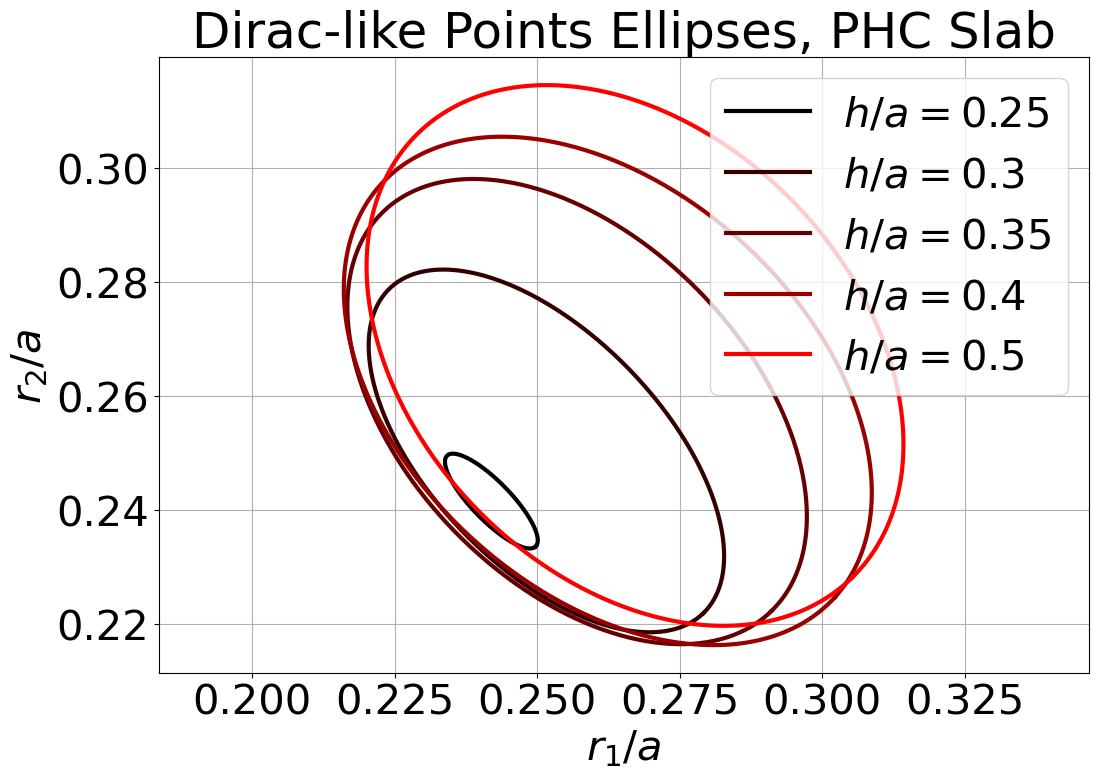

In [9]:
figure_ellipses = plt.figure(figsize=(12, 8))
figure_ellipses_no_point = plt.figure(figsize=(12, 8))
threshold = 1000
h_array = [0.25, 0.3, 0.35, 0.4, 0.5]
plt.figure(figure_ellipses)

plt.figure(figure_ellipses_no_point)
for h in h_array:
    try: 
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file  = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.figure(figure_ellipses_no_point)
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"$h/a = {h}$"})

plt.title(f"Dirac-like Points Ellipses, PHC Slab")
# equal axes
plt.axis("equal")
plt.legend()
plt.grid()
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.show()




<Figure size 1000x600 with 0 Axes>

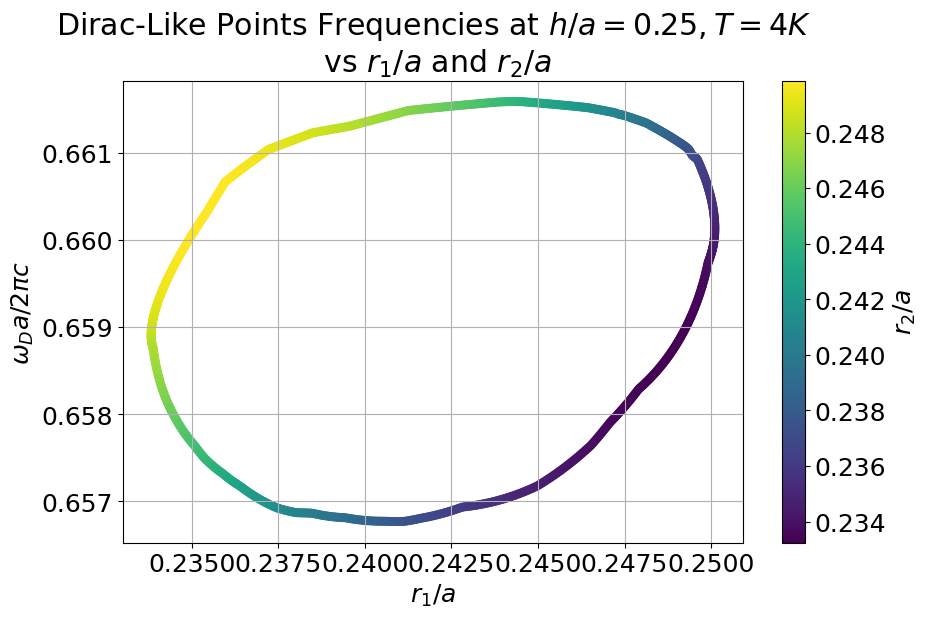

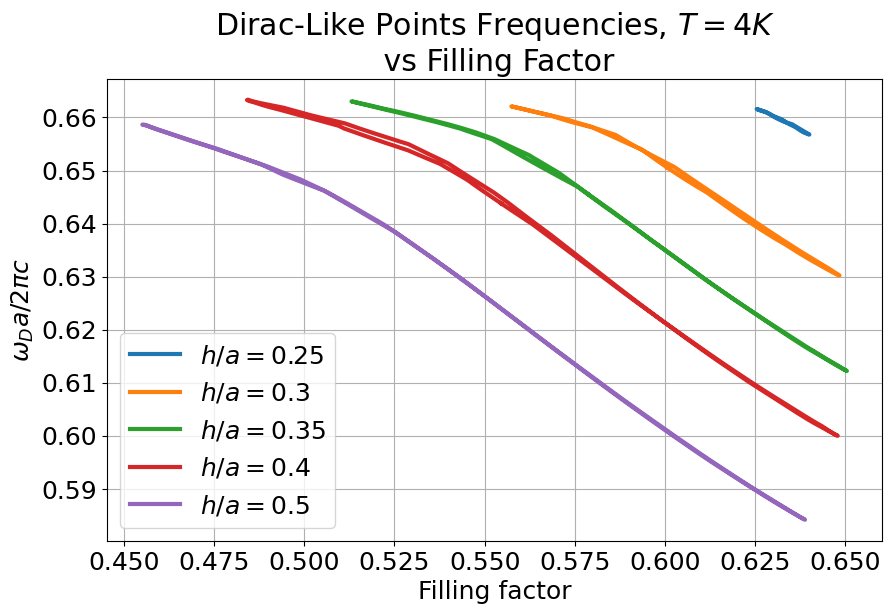

In [10]:
lambda0 = 1550
threshold = 1000
plt.rcParams["font.size"] = 18

## 0.25
fig1 = plt.figure(figsize=(10, 6))
fig2 = plt.figure(figsize=(10, 6))


colors = ["viridis", "plasma", "inferno", "magma", "cividis", "Greens"]
for i, h in enumerate([ 0.25 ]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold, n_points = 1000)
    plt.figure(fig1)
    plt.scatter(x, f, c = y, cmap=colors[i], label=f"$h/a = {h}$", s=30)

    
    
plt.figure(fig1)
plt.title(f"Dirac-Like Points Frequencies at $h/a = {h}, T={T}K$\n vs $r_1/a$ and $r_2/a$")
plt.grid()
plt.xlabel("$r_1/a$")
plt.ylabel("$\omega_{{D}}a/2\pi c$")
plt.colorbar(label="$r_2/a$")
plt.show()

for i, h in enumerate([ 0.25, 0.30, 0.35, 0.40, 0.50]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold, n_points = 1000)
    plt.figure(fig2)
    filling_factor =1- (x**2*np.pi + y**2*np.pi)
    plt.plot(filling_factor, f, "-", linewidth = 3, label=f"$h/a = {h}$")


plt.figure(fig2)
plt.xlabel("Filling factor")
plt.ylabel("$\omega_{{D}}a/2\pi c$")
plt.title(f"Dirac-Like Points Frequencies, $T={T}K$\n vs Filling Factor")
plt.grid()
plt.legend()
plt.show()
            

In [11]:
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
points = analyzer.get_points_above_treshold(1000)
#display(points)
print(analyzer.compute_param2_from_param1_on_ellipse(0.23,branch="lower", threshold=1000))

0.24255244407096266


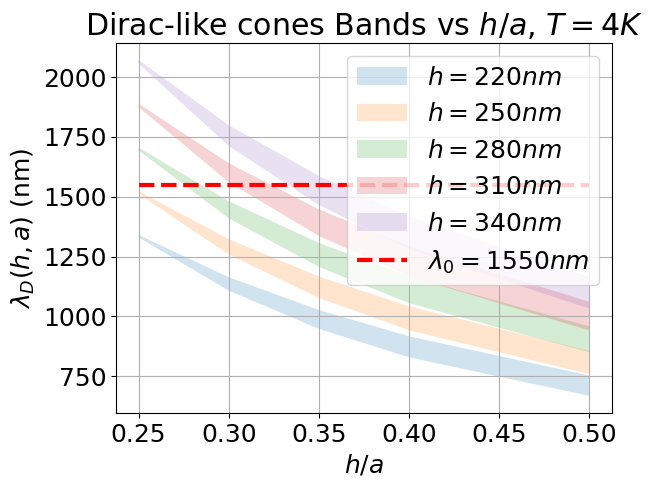

In [12]:
lam0 = 1550
threshold = 1000


## 0.35
ms = 8

f_mins = []
f_maxs = []
hs = []
for i, h in enumerate([0.25, 0.3, 0.35, 0.4, 0.5 ]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
   

    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)

    f_min = np.min(f)
    f_max = np.max(f)
    f_mins.append(f_min)
    f_maxs.append(f_max)
    hs.append(h)

wN_ll = []
for x in hs:
    h_phy = [ 220, 250, 280, 310, 340]
    lam = 1550
    wN_l = []
    for hi in h_phy:
        wN = hi/ lam / x
        wN_l.append(wN)
    wN_ll.append(wN_l)
wN_ll = np.array(wN_ll)



plt.figure()
for hi in h_phy: 
    lam_mins = []
    lam_maxs = []
    for x, fmin, fmax in zip(hs, f_mins, f_maxs):
        lam_min = hi/fmin/x
        lam_max = hi/fmax/x
        lam_mins.append(lam_min)
        lam_maxs.append(lam_max)
    plt.fill_between(hs, lam_mins, lam_maxs, alpha=0.2, label=f"$h = {hi}nm$")

plt.hlines(lam0, min(hs), max(hs), color="red", linestyle="--", label=f"$\lambda_0 = {lam0}nm$")
plt.xlabel("$h/a$")
plt.ylabel("$\lambda_D(h,a)$ (nm)")
plt.title(f"Dirac-like cones Bands vs $h/a$, $T={T}K$")
plt.legend()
plt.grid(True)
plt.show()

    

/zhome/2f/7/202918/phc_nzi/src/phc_nzi/optimization_data_analyzer.py:511: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


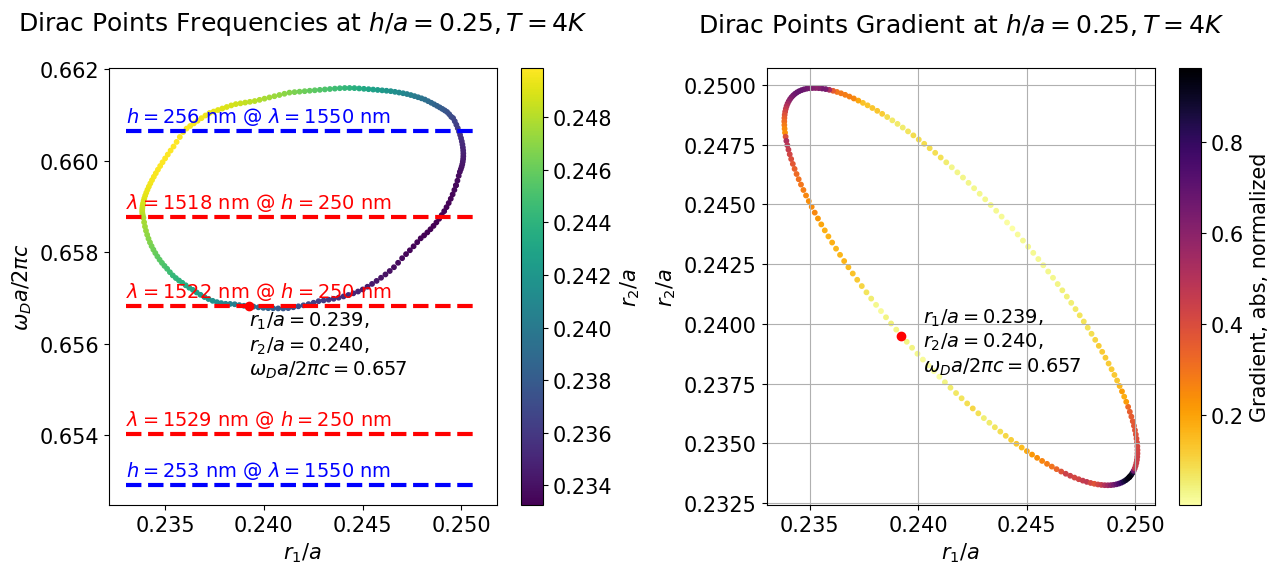

In [13]:
lambda0 = 1550
threshold = 1000

## 0.25

for i, h in enumerate([0.25]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    plt.rcParams["font.size"] = 15
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)   
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    lams = [   1518, 1529]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    h_phy = 250
    for lam in lams:
        w_target = h_phy / lam/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "red", linestyle = "--")
            plt.text(xlim[0], w_target+0.0002, f"$\lambda = {lam:0.0f}$ nm @ $h=250$ nm", color = "red", fontsize=14)

    h_phy_array = [ 253, 256]
    for h_phy_i in h_phy_array:
        w_target = h_phy_i / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "blue", linestyle = "--")
            plt.text(xlim[0], w_target+0.0002, f"$h = {h_phy_i:0.0f}$ nm @ $\lambda = 1550$ nm", color = "blue", fontsize=14)
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$\n")
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    f_lower = f[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Gradient, abs, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.text(param1_lower[idx_min]+0.001, param2_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$\n")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
   
    lam = h_phy/h/f_lower[idx_min]

    plt.hlines(f_lower[idx_min], xlim[0], xlim[1], color = "red", linestyle = "--")
    plt.text(xlim[0], f_lower[idx_min]+0.0002, f"$\lambda = {lam:0.0f}$ nm @ $h=250$ nm", color = "red", fontsize=14)
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    plt.text(param1_lower[idx_min], f_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
            
    # legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





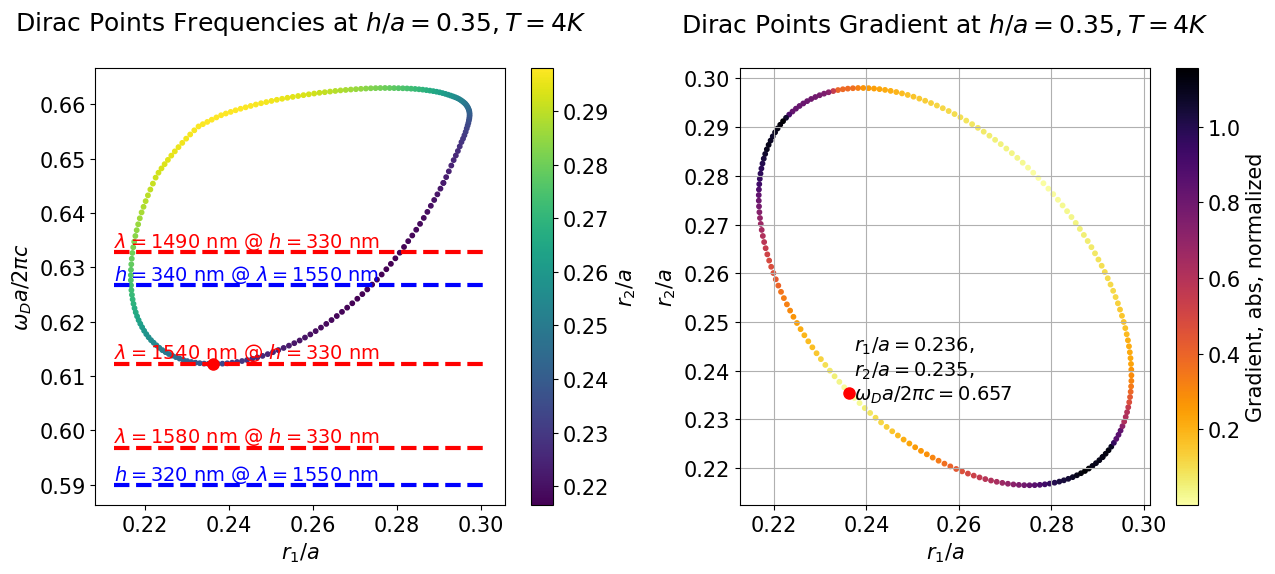

In [14]:
lambda0 = 1550
threshold = 1000

## 0.35
ms = 8
for i, h in enumerate([0.35]):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    plt.rcParams["font.size"] = 15
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)   
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    lams = [1580, 1490]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    h_phy = 330
    for lam in lams:
        w_target = h_phy / lam/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "red", linestyle = "--")
            plt.text(xlim[0], w_target+0.001, f"$\lambda = {lam:0.0f}$ nm @ $h={h_phy}$ nm", color = "red", fontsize=14)

    h_phy_array = [ 320,  340]
    for h_phy_i in h_phy_array:
        w_target = h_phy_i / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.hlines(w_target, xlim[0], xlim[1], color = "blue", linestyle = "--")
            plt.text(xlim[0], w_target+0.001, f"$h = {h_phy_i:0.0f}$ nm @ $\lambda = {lambda0}$ nm", color = "blue", fontsize=14)
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$\n")
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   

   

    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Gradient, abs, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$", markersize=ms)
    plt.text(param1_lower[idx_min]+0.001, param2_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$\n")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
   
    lam = h_phy/h/f_lower[idx_min]

    plt.hlines(f_lower[idx_min], xlim[0], xlim[1], color = "red", linestyle = "--")
    plt.text(xlim[0], f_lower[idx_min]+0.001, f"$\lambda = {lam:0.0f}$ nm @ $h={h_phy}$ nm", color = "red", fontsize=14)
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", markersize = ms)
    #plt.text(param1_lower[idx_min], f_lower[idx_min]-0.0015, f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n$r_2/a = {param2_lower[idx_min]:0.3f}$,\n$\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$", color = "black", fontsize=14)
            
    # legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





In [15]:
r1 = 0.24
hh = 0.25
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{hh:.3f}/{name_slab_opt}_p64_h_{hh:.3f}.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, threshold=1000, branch = "lower")
print(r2)


0.23872059228506468


## Sweep

In [16]:
# Instantiate the new sweeper
print("h:", hh, ", r1:", r1, ", r2:", r2)
# from nzi_phc.lsf_sweeper import LSFSweeper
values = np.linspace(0.225, 0.245, 64, endpoint=True)
sweeper = LSFSweeper(simulation_slab_sweep.simulation_name + "_r2", directory=simulation_slab_sweep.directory + "_r2",
                     scheme_script=simulation_slab_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="zeven",
                        bands=[8,9,10],
                        others_command_line_params={"r1": r1, "h": hh},
                       )

#Run the sweeper
# sweeper.submit_lsf_job(lsf_config)

h: 0.25 , r1: 0.24 , r2: 0.23872059228506468


0.24 0.23872059228506468


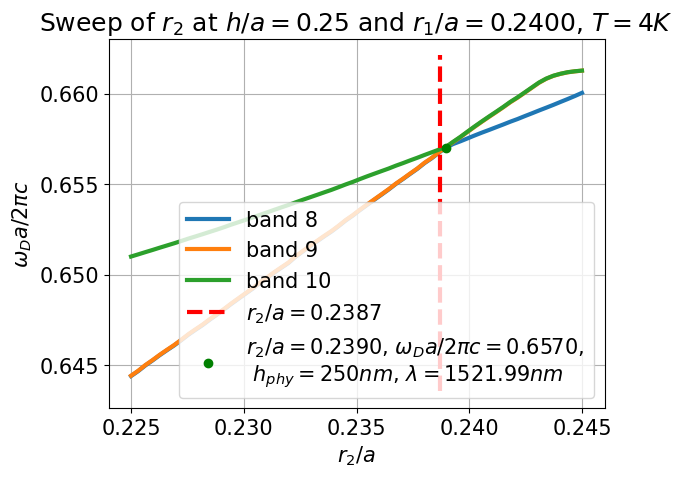

In [17]:
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.figure()

plt.plot(df["r2"], df["band_8"], label="band 8")
plt.plot(df["r2"], df["band_9"], label="band 9")
plt.plot(df["r2"], df["band_10"], label="band 10")
h_phy = 250

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {r2:0.4f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_10"] - df["band_8"]))
lamX = h_phy / hh / df["band_9"][idx_freq_dirac]
plt.plot(df["r2"][idx_freq_dirac], df["band_8"][idx_freq_dirac], "go", label = f"$r_2/a ={df['r2'][idx_freq_dirac]:0.4f}$, $\omega_Da/2\pi c = {df['band_8'][idx_freq_dirac]:0.4f}$, \n $h_{{phy}} =  {h_phy} nm$, $\lambda = {lamX:0.2f} nm$") 
plt.title(f"Sweep of $r_2$ at $h/a = {hh}$ and $r_1/a = {r1:0.4f}$, $T={T}K$")
plt.legend()
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

c0 = 299792458


## Optimized

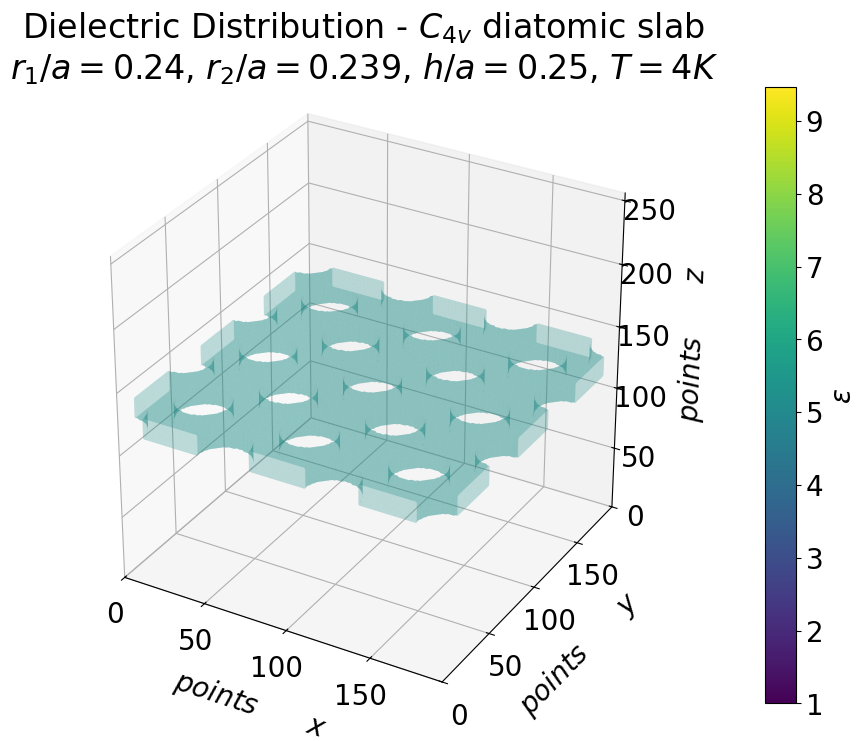

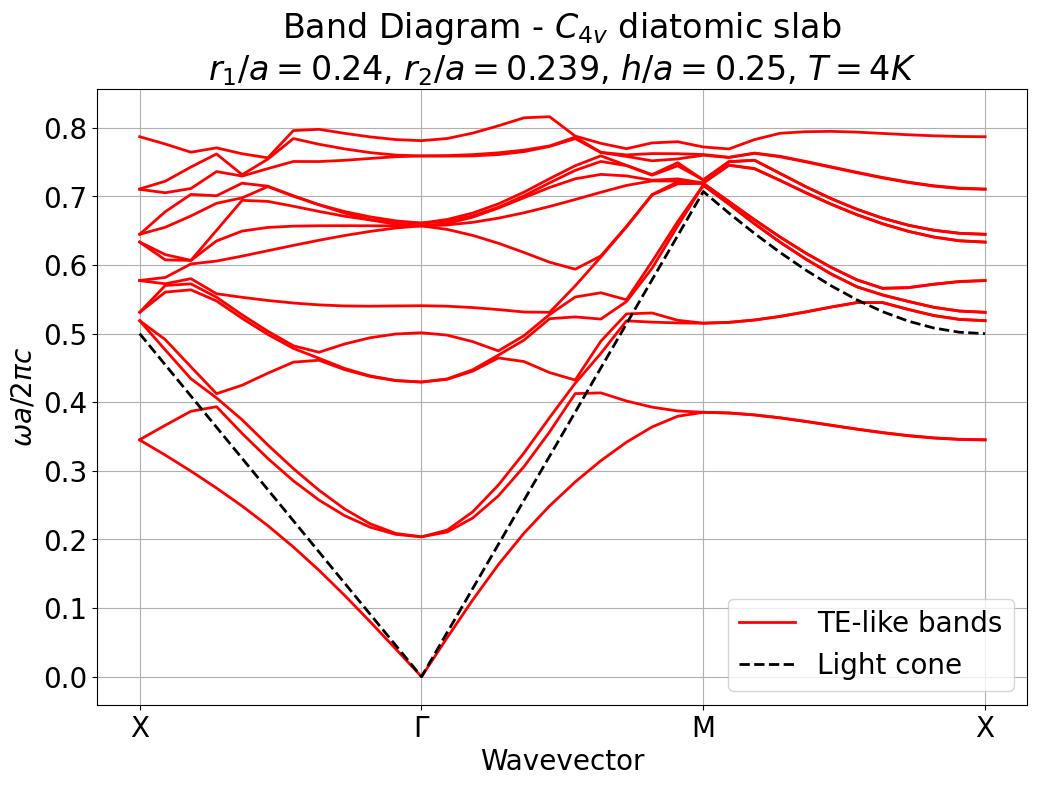

In [24]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
r1 = 0.24
r2 = 0.2390
hh=0.25
plt.rcParams["font.size"] = 20
#simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)
plt.rcParams["lines.linewidth"] = 2
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
plt.figure(figsize=(12, 8))
viewer_slab.plot_epsilon_3d(conversion_options=opt)
# Increase the distance between the labels and the axes
plt.xlabel("$points \qquad x$", labelpad=15)
plt.ylabel("$points \qquad y$", labelpad=15)
ax = plt.gca()
ax.set_zlabel("$points \qquad z$", labelpad=15)

plt.title(f"Dielectric Distribution - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.xlabel("$points \qquad x$")
plt.ylabel("$points \qquad y$")
ax = plt.gca()
ax.set_zlabel("$points \qquad z$")
viewer_slab.show()
plt.figure(figsize=(12, 8))
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points, color = "red", custom_label="TE-like bands")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.ylabel("$\omega a/2\pi c$")
df = simulation_slab.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)



# viewer_slab.show()
# figure, axes = plt.subplots(1, 3, figsize=(20, 6))

# data_line_slab = f"$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$"
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 10, "h", "z", "zeven", False, np.abs) 
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 10")
# c.set_label("$|H_{z}|$ (a.u.)")
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 9, "h", "z", "zeven", False, np.abs)
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 9")
# c.set_label("$|H_{z}|$ (a.u.)") 
# plt.figure()
# c = viewer_slab.plot_field_2d(1, 8, "h", "z", "zeven", False, np.abs)
# plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab+ " - Band 8")
# c.set_label("$|H_{z}|$ (a.u.)")
# plt.show()






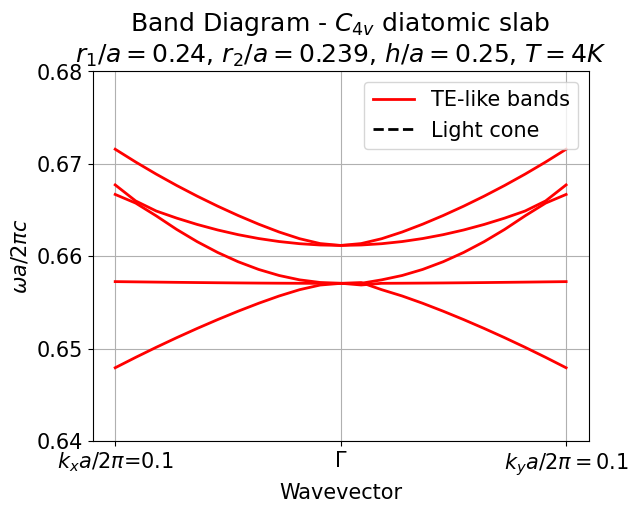

In [18]:
#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
r1 = 0.24
r2 = 0.2390
hh = 0.25

#simulation_slab_opt_centered.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh), LSFOptions=lsf_config)

plt.rcParams["lines.linewidth"] = 2
viewer_slab = SimulationViewer(simulation_slab_opt_centered) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points_around_gamma, color = "red", custom_label="TE-like bands")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.ylabel("$\omega a/2\pi c$")
ax = plt.gca()
ax.set_xticklabels([f"$k_x a/2\pi$={distance}", "$\Gamma$", f"$k_y a/2\pi={distance}$"])
df = simulation_slab_opt_centered.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)
plt.ylim(0.64,0.68)
viewer_slab.show()


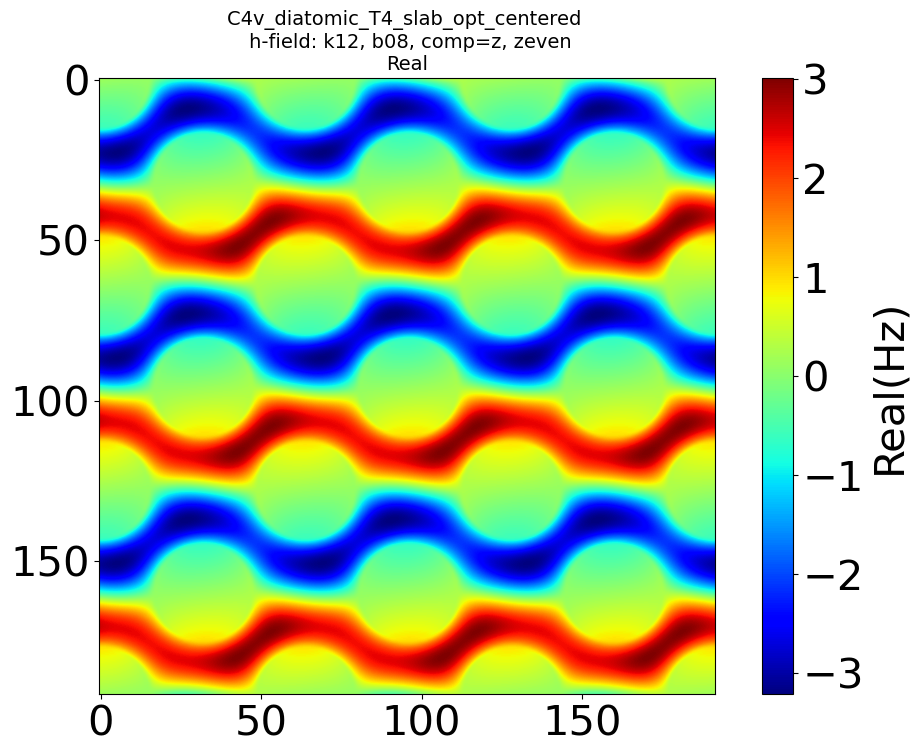

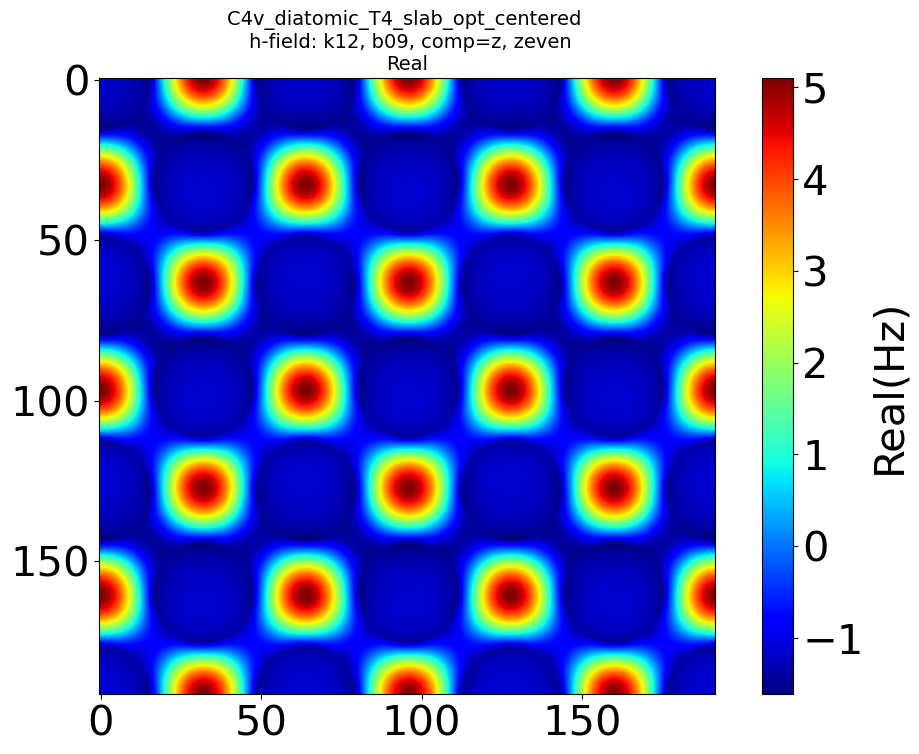

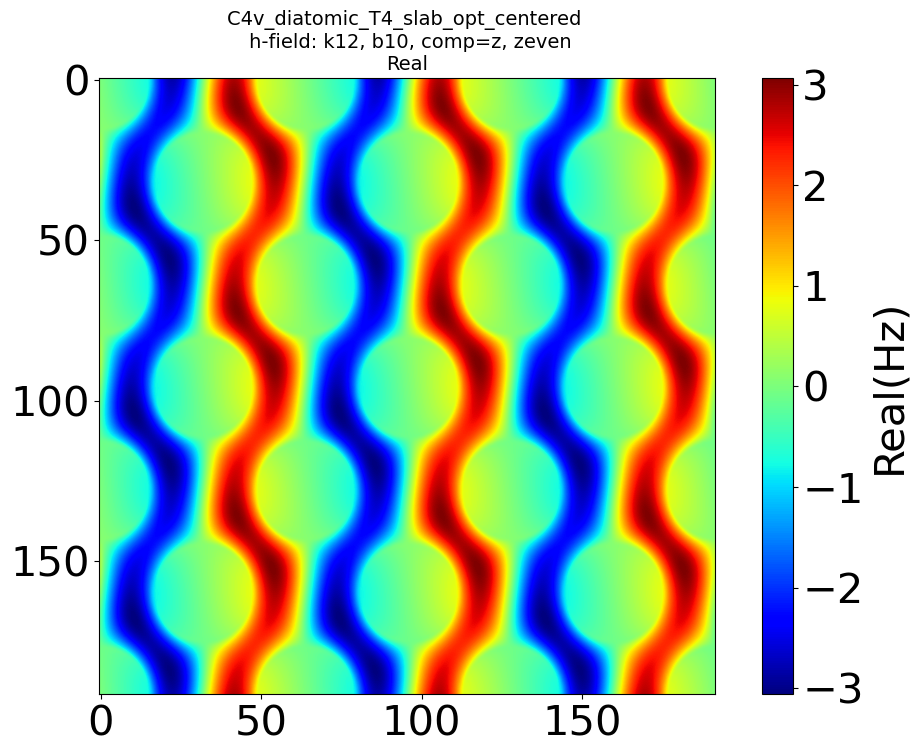

In [32]:
visualizer_slab = SimulationViewer(simulation_slab_opt_centered)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 8, "h", "z", "zeven", False, np.real)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 9, "h", "z", "zeven", False, np.real)
plt.figure(figsize=(12, 8))
visualizer_slab.plot_field_2d(12, 10, "h", "z", "zeven", False, np.real)
plt.show()

,k index,k1,k2,k3,kmag/2pi,zeven band 1,zeven band 2,zeven band 3,zeven band 4,zeven band 5,zeven band 6,zeven band 7,zeven band 8,zeven band 9,zeven band 10,zeven band 11,zeven band 12,zeven band 13,zeven band 14,zeven band 15
0,1,0.100000,0.000000,0,0.100000,0.087812,0.220762,0.226599,0.439246,0.440251,0.492511,0.539999,0.647918,0.657240,0.666675,0.667709,0.671569,0.754778,0.764794,0.787709
1,2,0.090909,0.000000,0,0.090909,0.079992,0.217886,0.222823,0.437559,0.438401,0.494048,0.540009,0.649044,0.657214,0.665739,0.665969,0.670183,0.755340,0.763834,0.786747
2,3,0.081818,0.000000,0,0.081818,0.072123,0.215265,0.219351,0.436029,0.436719,0.495439,0.540051,0.650130,0.657188,0.664360,0.664884,0.668876,0.755897,0.762949,0.785834
3,4,0.072727,0.000000,0,0.072727,0.064213,0.212905,0.216196,0.434658,0.435208,0.496682,0.540121,0.651173,0.657163,0.662888,0.664113,0.667646,0.756440,0.762143,0.784977
4,5,0.063636,0.000000,0,0.063636,0.056265,0.210811,0.213374,0.433445,0.433871,0.497777,0.540209,0.652174,0.657140,0.661564,0.663427,0.666490,0.756959,0.761421,0.784186
5,6,0.054545,0.000000,0,0.054545,0.048285,0.208985,0.210897,0.432392,0.432708,0.498722,0.540309,0.653131,0.657118,0.660395,0.662830,0.665406,0.757443,0.760787,0.783468
6,7,0.045455,0.000000,0,0.045455,0.040278,0.207434,0.208778,0.431500,0.431721,0.499519,0.540412,0.654041,0.657099,0.659391,0.662321,0.664393,0.757881,0.760243,0.782835
7,8,0.036364,0.000000,0,0.036364,0.032249,0.206159,0.207028,0.430770,0.430912,0.500168,0.540509,0.654898,0.657082,0.658558,0.661904,0.663456,0.758260,0.759794,0.782297
8,9,0.027273,0.000000,0,0.027273,0.024202,0.205164,0.205657,0.430201,0.430281,0.500671,0.540594,0.655686,0.657069,0.657903,0.661578,0.662608,0.758570,0.759442,0.781864
9,10,0.018182,0.000000,0,0.018182,0.016142,0.204451,0.204672,0.429794,0.429830,0.501029,0.540660,0.656369,0.657060,0.657431,0.661344,0.661884,0.758801,0.759189,0.781547


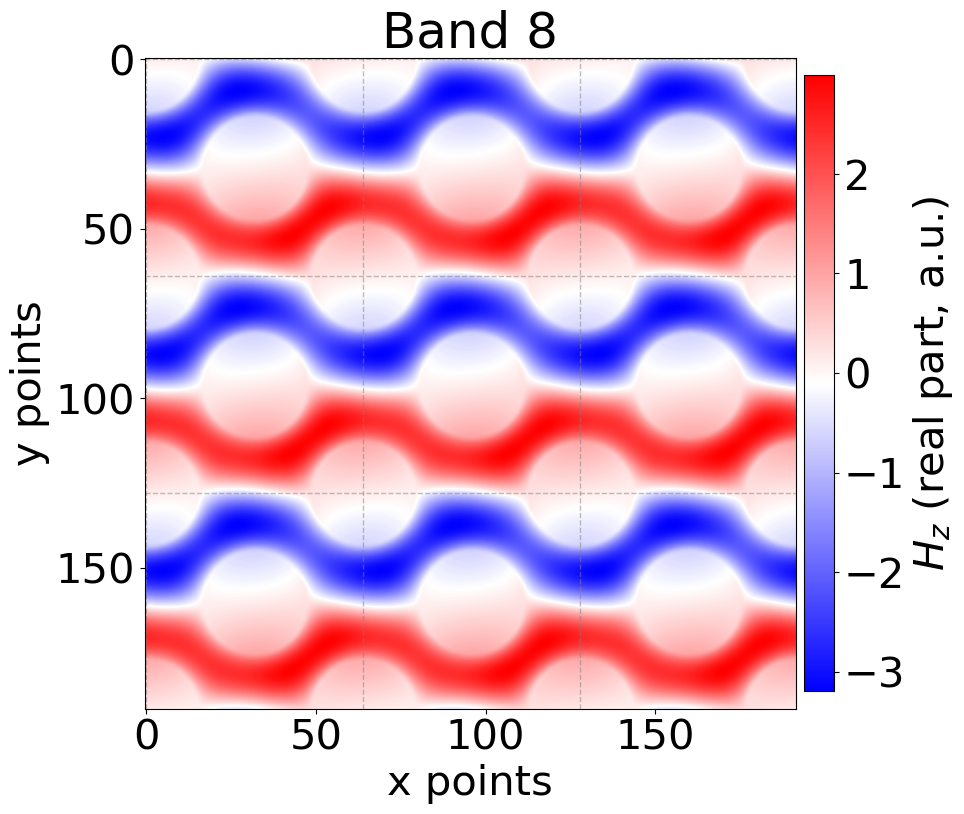

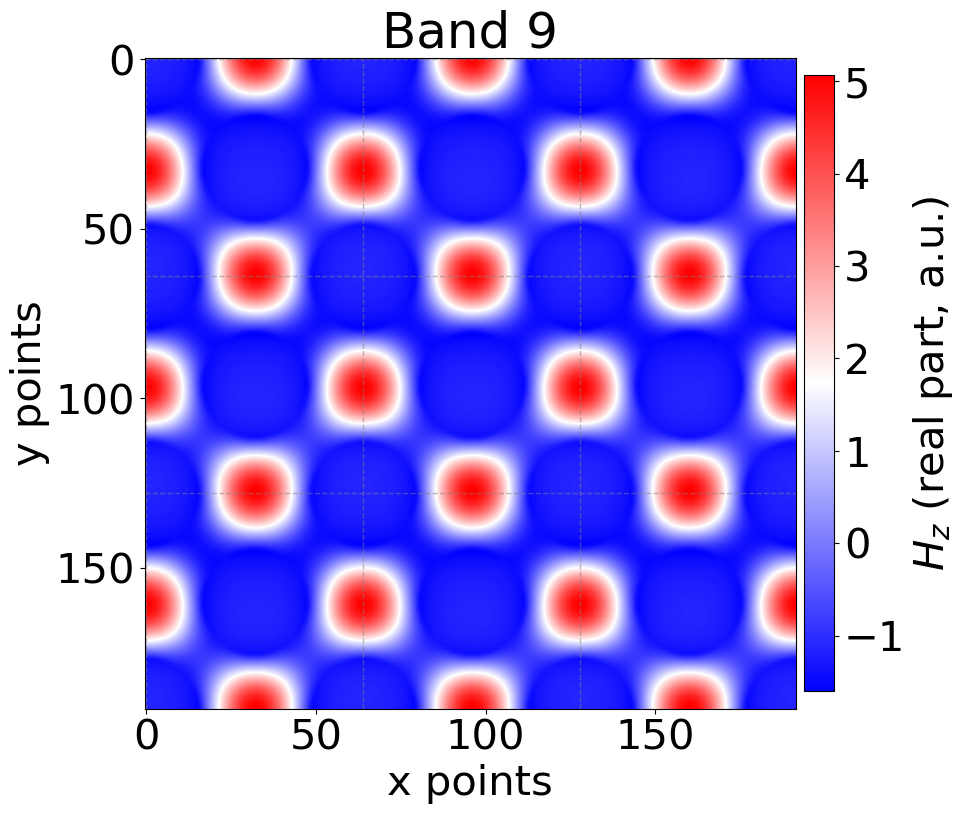

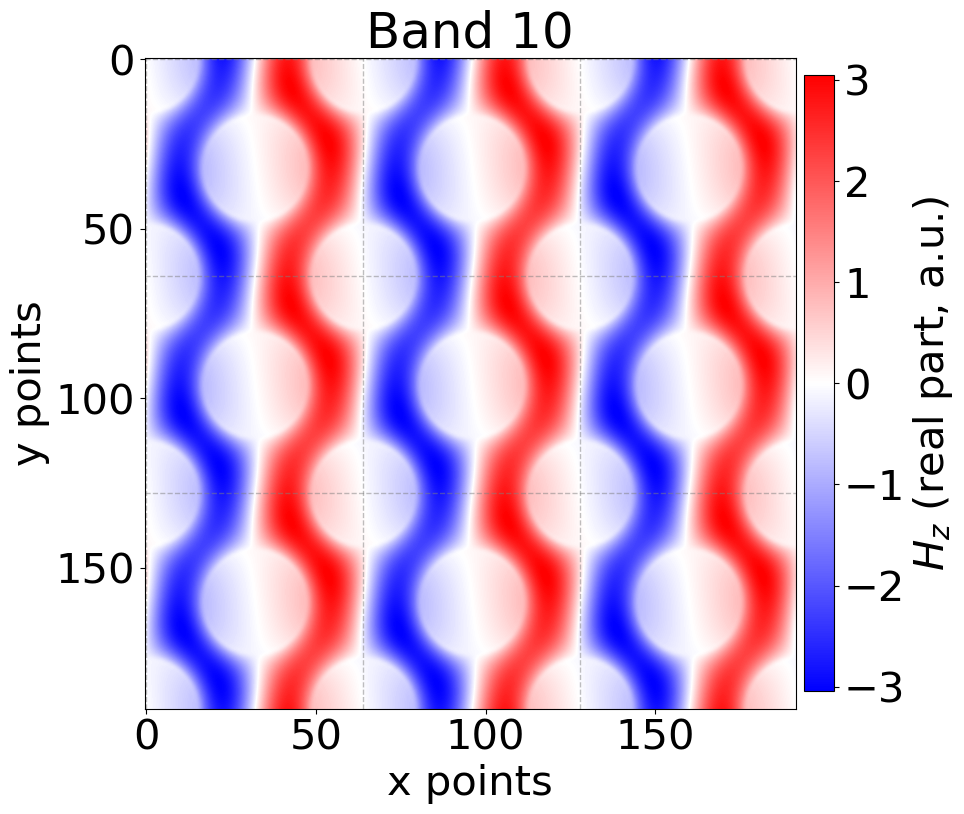

In [34]:
df = simulation_slab_opt_centered.load_frequency_data("zeven")
display(df)

plt.rcParams["font.size"] =30

def plot_field(k_idx, b_idx):
    opt = MPBDataOptions(rectify=True, periods= (3,3,1), transpose = False)
    # Load H-field (magnetic field) and E-field (electric field) components
    H_field = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "z", "zeven", "h", conversion_options=opt)
    # E_field_x = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "x", "zeven", "e", conversion_options=opt)
    # E_field_y = simulation_slab_opt_centered.load_and_convert_field_data(k_idx, b_idx, "y", "zeven", "e", conversion_options=opt)
    H_field = H_field[..., H_field.shape[2]//2-1]  # Take the middle slice for 2D visualization
    



    # Plot E-field as vectors with H-field as background
    plt.figure(figsize=(10, 10))
    # Background: H-field magnitude
    plt.imshow(np.real(H_field), interpolation='spline36', cmap="bwr")
    plt.colorbar(label="$H_{z}$ (real part, a.u.)", 
                 shrink=0.8, pad=0.01, aspect=20)
    
    # Prepare grid for quiver plot - subsample for clarity
    nx, ny = H_field.shape
    step = max(1, nx//30)  # Adjust arrow density
    X, Y = np.meshgrid(np.arange(0, nx, step), np.arange(0, ny, step))
    
    # # Sample E-field components
    # Ex = np.real(E_field_x[::step, ::step])
    # Ey = np.real(E_field_y[::step, ::step])
    
    # # Normalize arrows for better visualization
    # E_magnitude = np.sqrt(Ex**2 + Ey**2)
    # max_magnitude = np.max(E_magnitude)
    # if max_magnitude > 0:
    #     Ex = Ex / max_magnitude
    #     Ey = Ey / max_magnitude
    
    # # Plot vector field
    # plt.quiver(X, Y, Ex, Ey, angles='xy', scale=30, color='black', label="$E$-field vectors")
    # plt.legend(loc = "upper right")
    
    # Set plot title and labels
    
    plt.title(f"Band {b_idx}")
    plt.xlabel("x points")
    plt.ylabel("y points")
    # Draw grid lines every 64 points
    for i in range(0, nx, 64):
        plt.axvline(i, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    for j in range(0, ny, 64):
        plt.axhline(j, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    plt.show()


plot_field(12, 8)
plot_field(12, 9)
plot_field(12, 10)
